# Diversity Indices
In this notebook we explore diversity at both the population and individual level. The primary metrics explored here are heterozygosity and fraction of runs of homozygosity (*F<sub>ROH</sub>*). ANGSD was used to estimate largely 'SNP'-based heterozygosity, while SMOOVE was used to call and genotype SVs (as outlined in [03_SV_discovery_and_Genotyping.md]), while [ROHAN](https://github.com/grenaud/rohan) was used to call runs of homozygosity (ROHs) and estimate *F<sub>ROH</sub>*. The python packages below were used to clean, format and visualise our data.  

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib.legend_handler import HandlerTuple
import matplotlib.patches as patches
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import linregress
from sklearn.metrics import r2_score
from scipy.stats import mannwhitneyu
from scipy import stats

path = '/nesi/nobackup/uc03718/'
os.chdir(path)
print(os.getcwd())

/nesi/nobackup/uc03718


### Runs of Homozygosity 
 Following the recommendations, we removed all PCR-duplicates from BAM alignment files, estimated a transition/transversion ratio with [VCFtools](https://vcftools.github.io/index.html) v0.1.15, and defined an allowable level of heterozygosity within a 50kb window.  

In [ ]:
# Update with how I estimate base-pair frequency and use that instead of TSTV ratio to estimate ROH.

And the Ts/Tv ratio was estimated as a prior for ROHan with VCFtools using the BCF outputs from ANGSD.

In [ ]:
angsd -P 24 -b ${ANGSD}AU.list -ref $TREF -out ${ANGSD}samtools/genotypes/AU_genotypes \
    -uniqueOnly 1 -remove_bads 1 -only_proper_pairs 1 -trim 0 -C 50 -baq 1 \
    -minMapQ 20 -minQ 20 -minInd 19 -setMinDepth 200 -setMaxDepth 420 -doCounts 1 \
    -doPost 1 -doBcf 1 -GL 1 -doMajorMinor 1 -doMaf 1 -skipTriallelic 1 -SNP_pval 1e-6 -doGeno 10 --ignore-RG 0
vcftools --bcf ${ANGSD}samtools/genotypes/AU_genotypes.bcf \
    --TsTv-summary --out ${ANGSD}samtools/genotypes/AU_genotypes

angsd -P 24 -b ${ANGSD}TI.list -ref $TREF -out ${ANGSD}samtools/genotypes/TI_genotypes \
    -uniqueOnly 1 -remove_bads 1 -only_proper_pairs 1 -trim 0 -C 50 -baq 1 \
    -minMapQ 20 -minQ 20 -minInd 38 -setMinDepth 350 -setMaxDepth 830 -doCounts 1 \
    -doPost 1 -doBcf 1 -GL 1 -doMajorMinor 1 -doMaf 1 -skipTriallelic 1 -SNP_pval 1e-6 -doGeno 10 --ignore-RG 0
vcftools --bcf ${ANGSD}samtools/genotypes/TI_genotypes.bcf \
    --TsTv-summary --out ${ANGSD}samtools/genotypes/TI_genotypes

angsd -P 24 -b ${ANGSD}KI.list -ref $KREF -out ${ANGSD}samtools/genotypes/KI_genotypes \
    -uniqueOnly 1 -remove_bads 1 -only_proper_pairs 1 -trim 0 -C 50 -baq 1 \
    -minMapQ 20 -minQ 20 -minInd 24 -setMinDepth 700 -setMaxDepth 1200 -doCounts 1 \
    -doPost 1 -doBcf 1 -GL 1 -doMajorMinor 1 -doMaf 1 -skipTriallelic 1 -SNP_pval 1e-3 -doGeno 10 --ignore-RG 0
vcftools --bcf ${ANGSD}samtools/genotypes/KI_genotypes.bcf \
    --TsTv-summary --out ${ANGSD}samtools/genotypes/KI_genotypes

This resulted in a TsTv ratio of 1.871 for tara iti, 2.507 for Australian fairy tern, and 2.725 for kakī.  

Finally, ROHan was run with the `--rohmu` flag varied to ensure regions containing ROHs were detected as per [this discussion](https://github.com/grenaud/ROHan/issues/12#issuecomment-1935539239). The value of 5 x 10<sup>-5</sup> and a window size of 50kb equates 2.5 heterozygous genotypes within this window. For kakī, this threshold was left at the default setting of 1 x 10<sup>-5</sup> and equated to 0.5 heterozygous sites within a 50kb window. This much lower ROH threshold for kakī is attributable to the much higher sequence depth for the kakī data (i.e, target 50x vs 10x sequence depth).  

In [ ]:
for BAM in *_rohan.bam
    do
    BASE=$(basename $bam _rohan.bam)
    printf "STARTED RUNNING ROHAN FOR ${BASE} AT "
    date
    if [[ "$BASE" == "AU"*]]
        then
        rohan -t 16 --tstv 2.507 --size 50000 --rohmu 5e-5 -o output/${BASE} $TREF $BAM
    elif [[ "$BASE" == "H0"*]]
        then
        rohan -t 16 --tstv 2.725 --size 50000 -o output/${BASE} $KREF $BAM
    else
        rohan -t 16 --tstv 1.871 --size 50000 --rohmu 5e-5 -o output/${BASE} $TREF $BAM
    fi
    printf "FINISHED RUNNING ROHAN FOR ${BASE} AT "
    date
done

We then prepared summary plots for ROHs, one file each for tara iti and Australian fairy tern containing all ROH sizes calculated using the mid. estimates of heterozygosity.  

In [ ]:
for FILE in fairy_tern/rohmu_5e5/AU*.mid.hmmrohl.gz
    do
    BASE=$(basename $FILE .mid.hmmrohl.gz)
    zcat $FILE | tail -n+2 | cut -f 2-5 | awk -v SAMP="$BASE" '{ if ( $4 <= 200000 ) len="Short ROH";
        else if ( $4 > 200000 && $4 <= 700000 ) len ="Medium ROH";
        else len ="Long ROH";
        print SAMP"\t"$0"\t"len"\tAU"; }' >> ROHs.tsv
done

for FILE in fairy_tern/rohmu_5e5/{SND,SP,TI}*_subset.mid.hmmrohl.gz
    do
    BASE=$(basename $FILE _subset.mid.hmmrohl.gz)
    zcat $FILE | tail -n+2 | cut -f 2-5 | awk -v SAMP="$BASE" '{ if ( $4 <= 200000 ) len="Short ROH";
        else if ( $4 > 200000 && $4 <= 700000 ) len ="Medium ROH";
        else len ="Long ROH";
        print SAMP"\t"$0"\t"len"\tNZ"; }' >> ROHs.tsv
done

for FILE in kaki/rohmu_default/H0*.mid.hmmrohl.gz
    do
    BASE=$(basename $FILE .mid.hmmrohl.gz)
    zcat $FILE | tail -n+2 | cut -f 2-5 | awk -v SAMP="$BASE" '{ if ( $4 <= 200000 ) len="Short ROH";
        else if ( $4 > 200000 && $4 <= 700000 ) len ="Medium ROH";
        else len ="Long ROH";
        print SAMP"\t"$0"\t"len"\tKI"; }' >> ROHs.tsv
done

We also parsed a file with subsetting the summary files of all individuals.  

In [ ]:
printf "Sample\tSegments Unclassified\tSegments in ROH\tSegments in non-ROH\n" > rohan/ROH_segment_summary.txt

for FILE in rohan/rohmu_5e5/*.summary.txt
    do
    BASE=$(basename $FILE .summary.txt)
    echo $BASE
    UNCL=$(tail -n7 $FILE | head -n1 | awk '{print $4}')
    ROHS=$(tail -n5 $FILE | head -n1 | awk '{print $5}')
    NROH=$(tail -n3 $FILE | head -n1 | awk '{print $5}')
    printf "${BASE}\t${UNCL}\t${ROHS}\t${NROH}\n" >> rohan/ROH_segment_summary.txt
done

We use the python packages below to visualise Inbreeding represented as *F<sub>ROH</sub>*. We leverage ROH position, size estimates, and the number of segments (i.e., sites) used to infer ROH topography as determined by [ROHan]() to represent individual inbreeding the tara iti, AFT and kakī populations. 

We also examined the proportion of the genome impacted by ROHs for each individual of Australian fairy tern and tara iti. The higher count of ROHs in tara iti population also translated to a higher proportion of the genome impacted overall. However, the vast majority of ROHs impacting the genome is attributable to those in the 'large' (>700kb in length) category. This indicates that the tara iti population has remained chronically small for several generations.  

In [2]:
roh = pd.read_csv('rohan/ROHs.tsv', sep='\t')
exclude =['TI102', 'TI89', 'TI62', 'TI65', 'TI82', 'TI83', 'TI88', 'TI90', 'TI98', 'TI94', 'TI64', 'TI66', 'TI86', 'TI100', 'TI52', 'TI70', 'TI87']
roh = roh[~roh['Sample'].isin(exclude)]

roh_segments = pd.read_csv('rohan/ROH_segment_summary.txt', sep='\t')
chroms = pd.read_csv('rohan/chroms.tsv', sep='\t')

roh = roh.merge(chroms[['Chromosome', 'Chromosome Size']], on='Chromosome', how='left')

roh_summary = roh[['Sample', 'Size Class', 'Population']]
roh_summary = roh_summary.groupby(['Sample', 'Size Class', 'Population']).size().reset_index(name='ROH Counts')
roh_summary = roh_summary.sort_values('Size Class', ascending=False)
roh_summary['ROH_POP'] = roh_summary['Population'] + '-' + roh_summary['Size Class']

roh_segments['Total Segments Included'] = roh_segments['Segments in ROH'] + roh_segments['Segments in non-ROH']

roh_len = roh[['Sample', 'ROH Length', 'Size Class', 'Population']]
roh_len = roh_len.groupby(['Sample', 'Size Class', 'Population'])['ROH Length'].sum().reset_index(name='ROH Total')


roh_len = roh_len.merge(roh_segments[['Sample', 'Total Segments Included']], on='Sample', how='left')

roh_len['Proportion'] = roh_len['ROH Total'] / roh_len['Total Segments Included']

roh_len = roh_len.sort_values('Size Class', ascending=False)
roh_len['ROH_POP'] = roh_len['Population'] + '-' + roh_len['Size Class']

Here we examined the ROH size distrobution. However, because medium and larger ROHs occur at a much lower frequency than small ROH, it is challenging to visualise the distribution. To help allevieate this, we log10 transformed ROH length prior to plotting.  

In [3]:
with pd.option_context('display.float_format', '{:.2f}'.format):
    print(roh[roh['Population']=='KI'].groupby(['Sample'])['ROH Length'].mean().reset_index())

    Sample  ROH Length
0   H01383   299416.14
1   H01384   201498.56
2   H01385   224429.22
3   H01386   299249.42
4   H01387   317782.78
5   H01388   201818.63
6   H01389   306413.30
7   H01390   355478.59
8   H01391   190322.58
9   H01392   246300.00
10  H01393   287449.74
11  H01394   277444.99
12  H01395   242526.92
13  H01396   198184.10
14  H01397   312377.53
15  H01398   268728.42
16  H01399   219059.66
17  H01400   312229.99
18  H01401   296103.15
19  H01402   239294.65
20  H01403   254476.89
21  H01404   317279.41
22  H01405   230450.00
23  H01406   237893.16


## Population Diversity
### Runs of Homozygosity (ROHs)
We first examined the number of short (>50kb & <=200kb in length), medium (>200kb & <=700kb in length) and long (>700kb in length) ROHs per individual. This is to provide some indication of long-, medium- and short-term inbreeding levels respectively for each of the populations. Here, we can see that tara iti consistently have more ROHs across all three size classes.  

In [4]:
def mann_whitney_test(df, group_col, value_col, group1, group2):
    group1_values = df[df[group_col] == group1][value_col]
    group2_values = df[df[group_col] == group2][value_col]
    stat, p_value = mannwhitneyu(group1_values, group2_values, alternative='two-sided')
    return stat, p_value

# Perform the test for indiv_total
groups = ['AU-Short ROH', 'AU-Medium ROH', 'AU-Long ROH', 'NZ-Short ROH', 'NZ-Medium ROH', 'NZ-Long ROH', 'KI-Short ROH', 'KI-Medium ROH', 'KI-Long ROH']

results_total = {}

for i in range(len(groups)):
    for j in range(i + 1, len(groups)):
        group1 = groups[i]
        group2 = groups[j]
        stat, p_value = mann_whitney_test(roh_summary, 'ROH_POP', 'ROH Counts', group1, group2)
        results_total[f'{group1} vs {group2}'] = {'stat': stat, 'p_value': p_value}

# Print the results
print("Mann-Whitney U Test results for ROH counts:")
for comparison, result in results_total.items():
    print(f"{comparison}: U-statistic = {result['stat']}, p-value = {result['p_value']}")


Mann-Whitney U Test results for ROH counts:
AU-Short ROH vs AU-Medium ROH: U-statistic = 361.0, p-value = 1.4728853070303523e-07
AU-Short ROH vs AU-Long ROH: U-statistic = 361.0, p-value = 1.4207436261002553e-07
AU-Short ROH vs NZ-Short ROH: U-statistic = 21.0, p-value = 1.122535080643894e-08
AU-Short ROH vs NZ-Medium ROH: U-statistic = 478.5, p-value = 0.028570379093541504
AU-Short ROH vs NZ-Long ROH: U-statistic = 703.0, p-value = 1.235529899997307e-09
AU-Short ROH vs KI-Short ROH: U-statistic = 0.0, p-value = 2.638044719210391e-08
AU-Short ROH vs KI-Medium ROH: U-statistic = 39.0, p-value = 4.018168488469909e-06
AU-Short ROH vs KI-Long ROH: U-statistic = 456.0, p-value = 2.6316966627114692e-08
AU-Medium ROH vs AU-Long ROH: U-statistic = 361.0, p-value = 1.418513185426635e-07
AU-Medium ROH vs NZ-Short ROH: U-statistic = 0.0, p-value = 1.2427470260703717e-09
AU-Medium ROH vs NZ-Medium ROH: U-statistic = 0.0, p-value = 1.2427470260703717e-09
AU-Medium ROH vs NZ-Long ROH: U-statistic = 

In [3]:
roh_proportion = roh.groupby(['Sample', 'Population'])['ROH Length'].sum().reset_index(name='ROH Total')
indiv_roh_counts = roh.groupby(['Sample', 'Population'])['ROH Length'].count().reset_index(name='Count').sort_values('Count')
roh_segments = pd.read_csv('rohan/ROH_segment_summary.txt', sep='\t')
roh_segments['Total Segments Included'] = roh_segments['Segments in ROH'] + roh_segments['Segments in non-ROH']

roh_proportion = roh_proportion.merge(roh_segments[['Sample', 'Total Segments Included']], on='Sample', how='left')
roh_proportion['Froh'] = roh_proportion['ROH Total'] / roh_proportion['Total Segments Included']

roh_proportion.sort_values('Froh')

groups = ['AU', 'NZ', 'KI']

for i in range(len(groups)):
    standard_dev = roh_proportion[roh_proportion['Population']==groups[i]]['Froh'].std()
    count = roh_proportion[roh_proportion['Population']==groups[i]]['Froh'].count()
    standard_err = standard_dev / np.sqrt(count)
    print(f"Mean individual FROH for {groups[i]}: {roh_proportion[roh_proportion['Population']==groups[i]]['Froh'].mean()} +/- {standard_err}")


Mean individual FROH for AU: 0.07738820920883634 +/- 0.0025104285507874502
Mean individual FROH for NZ: 0.6597833546986756 +/- 0.007874282055716837
Mean individual FROH for KI: 0.5210378527522576 +/- 0.013412510655278822


In [6]:
groups = ['AU-Short ROH', 'AU-Medium ROH', 'AU-Long ROH', 'NZ-Short ROH', 'NZ-Medium ROH', 'NZ-Long ROH', 'KI-Short ROH', 'KI-Medium ROH', 'KI-Long ROH']

results_total = {}

for i in range(len(groups)):
    for j in range(i + 1, len(groups)):
        group1 = groups[i]
        group2 = groups[j]
        stat, p_value = mann_whitney_test(roh_len, 'ROH_POP', 'Proportion', group1, group2)
        results_total[f'{group1} vs {group2}'] = {'stat': stat, 'p_value': p_value}

# Print the results
print("Mann-Whitney U Test results for FROH:")
for comparison, result in results_total.items():
    print(f"{comparison}: U-statistic = {result['stat']}, p-value = {result['p_value']}")

Mann-Whitney U Test results for FROH:
AU-Short ROH vs AU-Medium ROH: U-statistic = 322.0, p-value = 3.847371474424406e-05
AU-Short ROH vs AU-Long ROH: U-statistic = 341.0, p-value = 2.995041856121807e-06
AU-Short ROH vs NZ-Short ROH: U-statistic = 4.0, p-value = 1.914624602835668e-09
AU-Short ROH vs NZ-Medium ROH: U-statistic = 0.0, p-value = 1.2467728339679515e-09
AU-Short ROH vs NZ-Long ROH: U-statistic = 0.0, p-value = 1.2467728339679515e-09
AU-Short ROH vs KI-Short ROH: U-statistic = 0.0, p-value = 2.64122377673511e-08
AU-Short ROH vs KI-Medium ROH: U-statistic = 0.0, p-value = 2.64122377673511e-08
AU-Short ROH vs KI-Long ROH: U-statistic = 0.0, p-value = 2.64122377673511e-08
AU-Medium ROH vs AU-Long ROH: U-statistic = 327.0, p-value = 2.0221305879843327e-05
AU-Medium ROH vs NZ-Short ROH: U-statistic = 0.0, p-value = 1.2467728339679515e-09
AU-Medium ROH vs NZ-Medium ROH: U-statistic = 0.0, p-value = 1.2467728339679515e-09
AU-Medium ROH vs NZ-Long ROH: U-statistic = 0.0, p-value = 1

In [7]:
print(roh_proportion[roh_proportion['Population']=='NZ'].sort_values(by='Froh', ascending=True))

   Sample Population  ROH Total  Total Segments Included      Froh
49   TI21         NZ  513850000               1024550000  0.501537
45  SND11         NZ  589450000               1047750000  0.562586
44  SND06         NZ  610650000               1059850000  0.576166
43  SND04         NZ  617750000               1059100000  0.583278
54   TI40         NZ  648400000               1069550000  0.606236
50   TI35         NZ  657300000               1081850000  0.607570
47   SP03         NZ  674900000               1078350000  0.625864
71   TI84         NZ  683850000               1076950000  0.634988
69   TI78         NZ  692950000               1089200000  0.636201
48  TI101         NZ  703650000               1097100000  0.641373
53   TI38         NZ  711400000               1100200000  0.646610
64   TI69         NZ  709250000               1089250000  0.651136
63   TI68         NZ  723250000               1101750000  0.656456
55   TI41         NZ  724800000               1102300000  0.65

The individuals with the smallest, median, and largest *F<sub>ROH</sub>* for each group.  
- Australian fairy tern
    - Smallest *F<sub>ROH</sub>*: AU13 (6.077%)
    - Median *F<sub>ROH</sub>*: AU06 (7.2622%)
    - Largest *F<sub>ROH</sub>*: AU03 (10.4434%)
- Tara iti
    - Smallest *F<sub>ROH</sub>*: TI21 (50.1537%)
    - Median *F<sub>ROH</sub>*: TI54 (66.241%)
    - Largest *F<sub>ROH</sub>*: TI92 (72.5391%)
- Kakī
    - Smallest *F<sub>ROH</sub>*: H01396 (37.0804%)
    - Median *F<sub>ROH</sub>*: H01397 (53.6666%)
    - Largest *F<sub>ROH</sub>*: H01387 (61.6754%)

In [10]:
def plot_roh_multi_samples(samples, roh_df, bin_size=10_000, figsize=(20, 6), show_legend=False):
    """
    Plot ROH regions for multiple samples in vertically arranged subplots.
    Colors are based on ROH Class instead of overlap heatmap.
    
    Parameters:
    samples: list of 3 sample names
    roh_df: DataFrame containing ROH data with columns including 'Sample', 'Chromosome', 'Start', 'End', 'ROH Class'
    bin_size: bin size for plotting (default 10,000)
    figsize: figure size tuple
    show_legend: boolean to control legend display (default True)
    """
    
    if len(samples) != 3:
        raise ValueError("Exactly 3 samples must be provided")
    
    # Define color map for ROH Classes
    # You can customize these colors based on your ROH classes
    size_class_colors = {
        'Short ROH': 'seagreen',     # Red
        'Medium ROH': 'wheat',    # Teal  
        'Long ROH': 'coral',      # Blue
        # Add more classes as needed
    }
    
     # Get chromosome information from first sample
    sample_data = roh_df[roh_df['Sample'] == samples[0]]
    if sample_data.empty:
        raise ValueError(f"No data found for sample {samples[0]}")
    
    # Get all chromosomes and their sizes from the ROH data
    all_samples_data = roh_df[roh_df['Sample'].isin(samples)]
    
    # Use the 'Chromosome Size' column from the dataframe
    chrom_info = all_samples_data[['Chromosome', 'Chromosome Size']].drop_duplicates()
    chrom_sizes = dict(zip(chrom_info['Chromosome'], chrom_info['Chromosome Size']))
    
    # Sort chromosomes (customize this order as needed)
    chrom_order = sorted(chrom_sizes.keys(), key=lambda x: chrom_sizes[x], reverse=True)
    
    # Create figure with 3 vertically stacked subplots
    fig, axes = plt.subplots(3, 1, figsize=figsize, sharex=True)
    
    # Calculate cumulative positions for chromosomes
    cumulative_pos = 0
    chrom_positions = {}
    chrom_boundaries = []
    
    for chrom in chrom_order:
        chrom_positions[chrom] = cumulative_pos
        cumulative_pos += chrom_sizes[chrom]
        chrom_boundaries.append(cumulative_pos)
    
    total_genome_size = cumulative_pos
    
    # Plot each sample
    for idx, sample in enumerate(samples):
        ax = axes[idx]
        sample_roh = roh_df[roh_df['Sample'] == sample]
        
        if sample_roh.empty:
            print(f"Warning: No ROH data found for sample {sample}")
            ax.text(0.5, 0.5, f'No data for {sample}', transform=ax.transAxes, 
                   ha='center', va='center', fontsize=12)
            ax.set_ylabel(sample, rotation=0, ha='right', va='center')
            continue
        
        # Get unique Size classes for this sample
        size_classes = sample_roh['Size Class'].unique()
        
        # Plot ROH regions for each class
        for size_class in size_classes:
            class_data = sample_roh[sample_roh['Size Class'] == size_class]
            color = size_class_colors.get(size_class, '#808080')  # Default gray if class not found
            
            for _, roh in class_data.iterrows():
                chrom = roh['Chromosome']
                if chrom in chrom_positions:
                    start_pos = chrom_positions[chrom] + roh['Start']
                    end_pos = chrom_positions[chrom] + roh['End']
                    width = end_pos - start_pos
                    
                    # Create rectangle for ROH region
                    rect = patches.Rectangle((start_pos, 0), width, 1, 
                                           facecolor=color, edgecolor='none', alpha=0.8)
                    ax.add_patch(rect)
        
        # Customize subplot
        #ax.set_ylabel(sample, rotation=0, ha='right', va='center', fontsize=12)
        ax.set_ylim(0, 1)
        ax.set_xlim(0, total_genome_size)
        
        # Add chromosome boundaries with black dashed lines
        for boundary in chrom_boundaries[:-1]:  # Skip the last boundary
            ax.axvline(x=boundary, color='black', linestyle='--', alpha=0.7, linewidth=2)
        
        # Remove y-ticks
        ax.set_xticks([])
        ax.set_yticks([])
        
        # Only show x-axis labels on bottom plot
        #if idx < 2:
        #    ax.set_xticks([])
    
    # Add chromosome labels on bottom plot
    #bottom_ax = axes[2]
    chrom_centers = []
    chrom_labels = []
    
    for chrom in chrom_order:
        center = chrom_positions[chrom] + chrom_sizes[chrom] / 2
        chrom_centers.append(center)
        chrom_labels.append(str(chrom))
    
    #bottom_ax.set_xticks(chrom_centers)
    #bottom_ax.set_xticklabels(chrom_labels, rotation=45, ha='right')
    #bottom_ax.set_xlabel('Chromosome', fontsize=12)
    
    # Create legend for Size classes (only if show_legend is True)
    if show_legend:
        legend_elements = []
        for size_class, color in size_class_colors.items():
            # Only include classes that appear in the data
            if any(size_class in roh_df[roh_df['Sample'] == sample]['Size Class'].values for sample in samples):
                legend_elements.append(patches.Patch(color=color, label=size_class))
        
        if legend_elements:
            fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.95))
    
    plt.tight_layout()
    return fig, axes

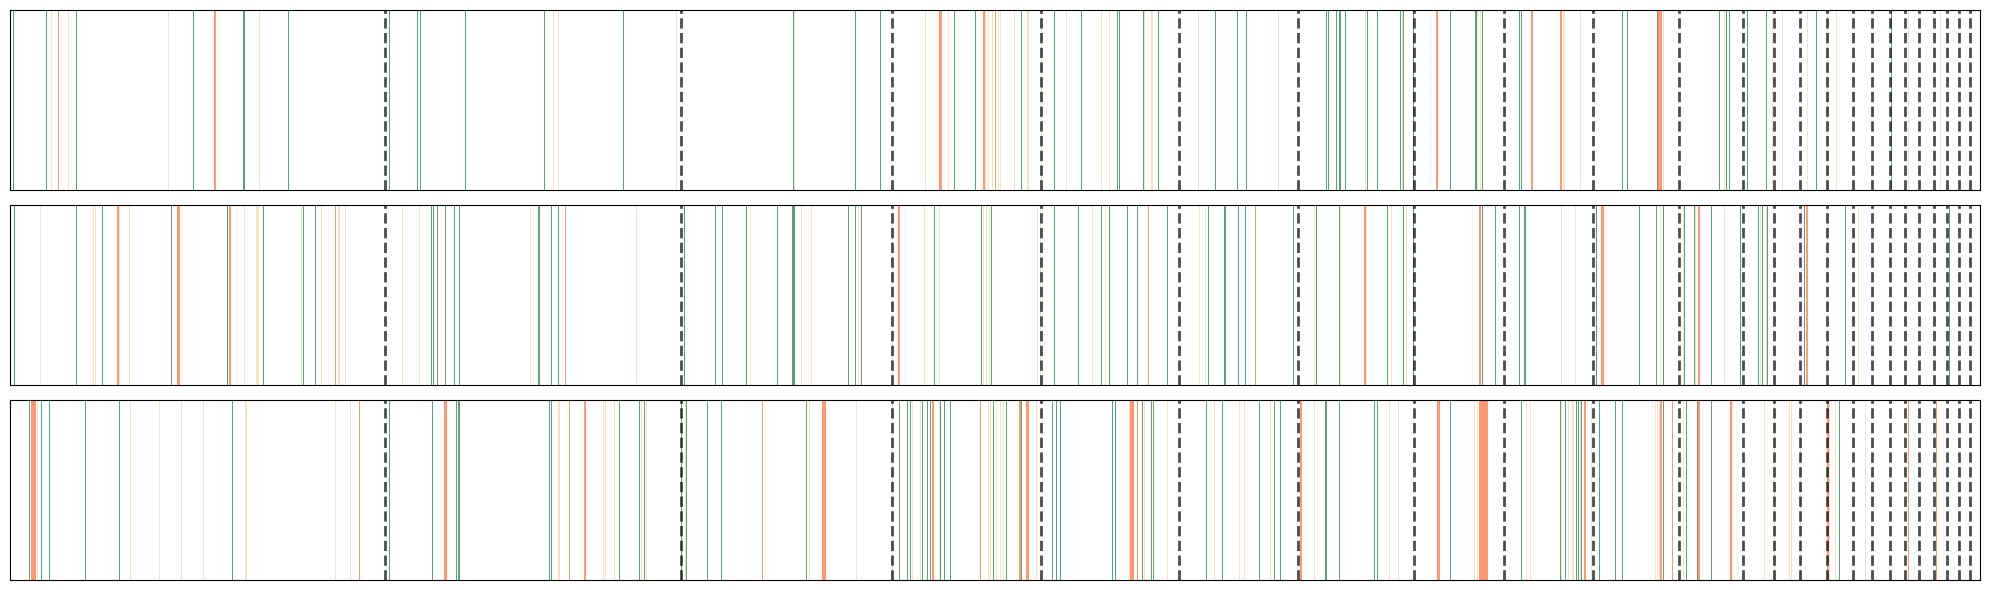

In [ ]:
# Usage example:
# Define your 3 samples
samples_to_plot = ['AU13', 'AU06', 'AU03']  # Replace with your actual sample names

# Create the multi-sample plot
fig, axes = plot_roh_multi_samples(samples_to_plot, roh)

plt.savefig('Git_Repos/2026_S_nereis_Cons_Gen/Figures/AU_indiv_roh.png', dpi=300, bbox_inches='tight')

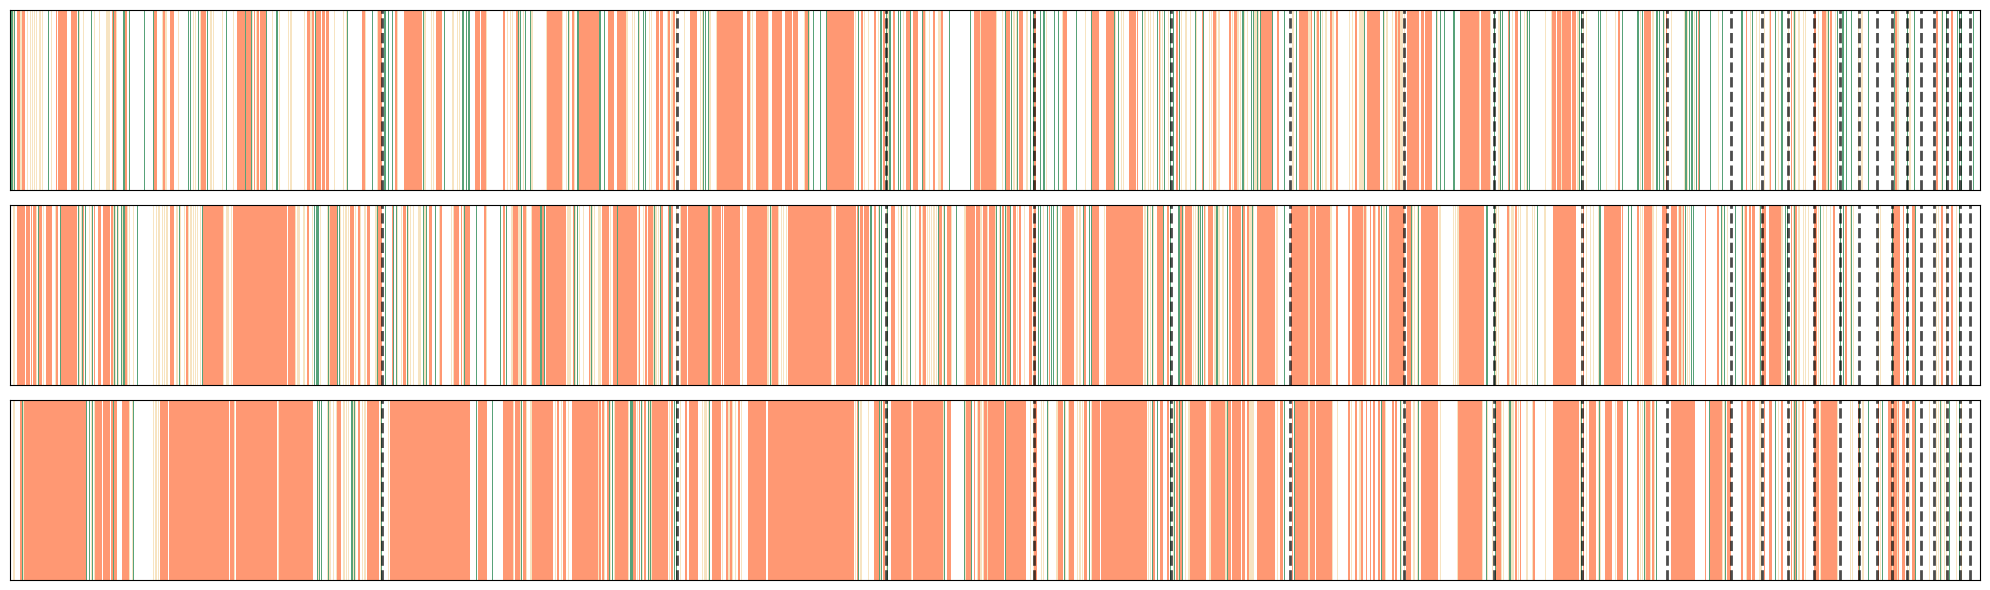

<Figure size 640x480 with 0 Axes>

In [ ]:
# Usage example:
# Define your 3 samples
samples_to_plot = ['TI21', 'TI54', 'TI92']  # Replace with your actual sample names

# Create the multi-sample plot
fig, axes = plot_roh_multi_samples(samples_to_plot, roh)
plt.show()

plt.savefig('Git_Repos/2026_S_nereis_Cons_Gen/Figures/NZ_indiv_roh.png', dpi=300, bbox_inches='tight')

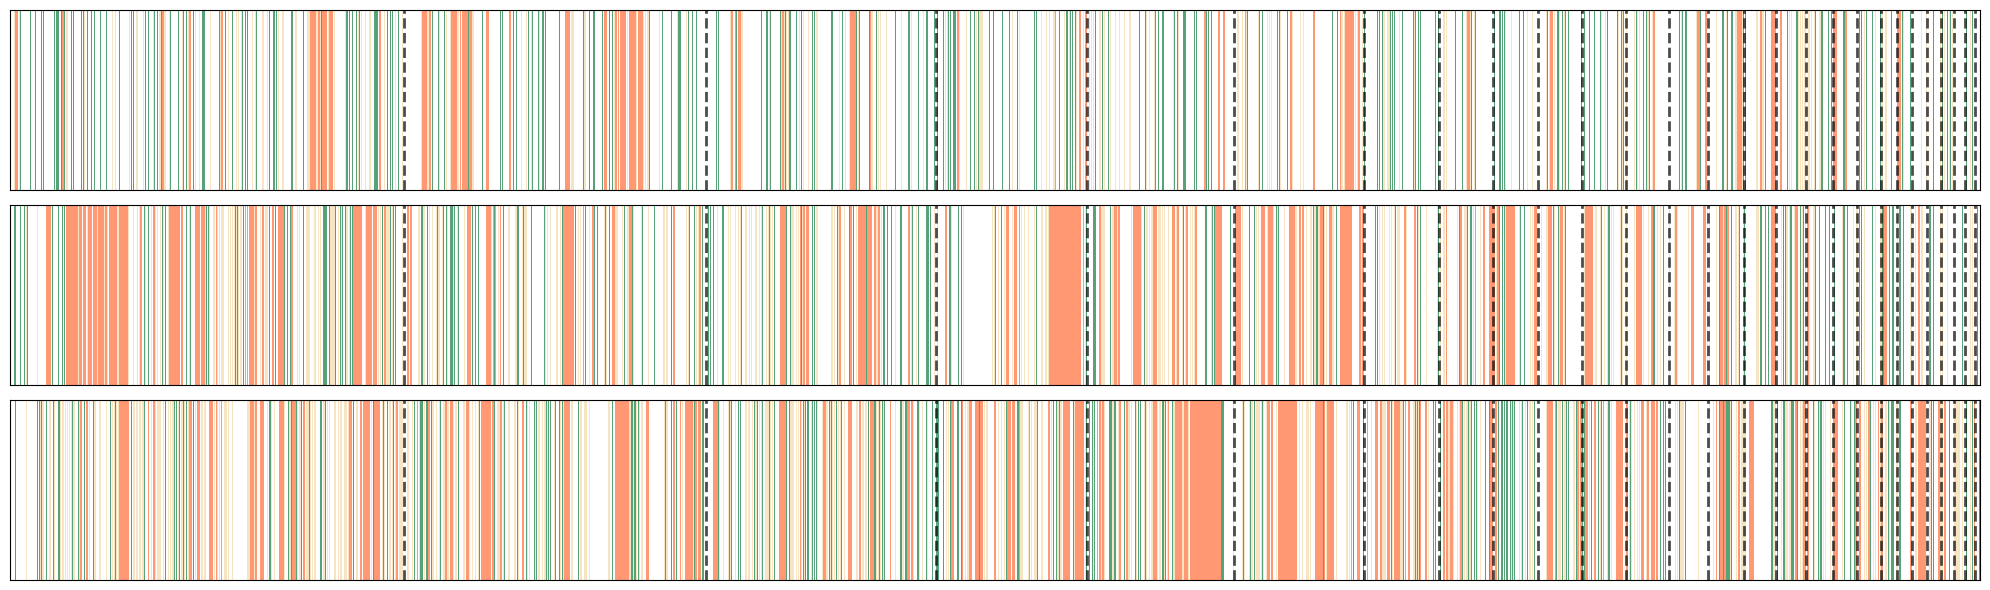

In [13]:
# Usage example:
# Define your 3 samples
samples_to_plot = ['H01396', 'H01397', 'H01387']  # Replace with your actual sample names

# Create the multi-sample plot
fig, axes = plot_roh_multi_samples(samples_to_plot, roh)

plt.savefig('Git_Repos/2026_S_nereis_Cons_Gen/Figures/KI_indiv_roh.png', dpi=300, bbox_inches='tight')

We then examined the density of Runs of Homozygosity (ROHs) by size class. Here, we plot ROHs presence at a particular location across individuals for chromosome 1 as a means to visualise relative *fROH* among individuals.  

To start, we load and subset the original `ROH_density.tsv` file by population, ROH size class, and position (`BEGIN` and `END`).  

We then define a plot function that marks the presence/absence of ROHs by their `BEGIN` and `END` position along chromosome 1. The color `seagreen` denotes ROHs smaller than or equal to 200kb in length, `wheat` indicates ROHs larger than 200kb and smaller than or equal to 700kb, and `coral` represents ROHs larger than 700kb.  

In [9]:
roh = pd.read_csv('rohan/ROHs.tsv', sep='\t')
exclude =['TI102', 'TI89', 'TI62', 'TI65', 'TI82', 'TI83', 'TI88', 'TI90', 'TI98', 'TI94', 'TI64', 'TI66', 'TI86', 'TI100', 'TI52', 'TI70', 'TI87']
roh = roh[~roh['Sample'].isin(exclude)]

roh_proportion = roh.groupby(['Sample', 'Population'])['ROH Length'].sum().reset_index(name='ROH Total')
indiv_roh_counts = roh.groupby(['Sample', 'Population'])['ROH Length'].count().reset_index(name='Count').sort_values('Count')

chr = pd.read_csv('rohan/chroms.tsv', sep='\t')

roh_segments = pd.read_csv('rohan/ROH_segment_summary.txt', sep='\t')
roh_segments = roh_segments[~roh_segments['Sample'].isin(exclude)]
roh_segments['Total Segments Included'] = roh_segments['Segments in ROH'] + roh_segments['Segments in non-ROH']

roh = roh.merge(chr[['Chromosome', 'Chromosome Size']], on='Chromosome', how='left')
roh = roh.merge(roh_segments[['Sample', 'Total Segments Included']], on='Sample', how='left')

roh_proportion = roh_proportion.merge(roh_segments[['Sample', 'Total Segments Included']], on='Sample', how='left')
roh_proportion['Froh'] = roh_proportion['ROH Total'] / roh_proportion['Total Segments Included']

In [5]:
def plot_easyFroh_distribution(
    df, population,
    column='Froh',
    xlim=(0, 1),
    bin_width=0.02,
    dpi=300,
    color='steelblue',
    box_color='black',
    save_path=None
):
    """
    Plot horizontal violin + boxplot (top) and histogram (bottom) for a given population.

    Parameters:
    - df: pandas DataFrame with 'Population' and target column
    - population: str, value to filter from df['Population']
    - column: str, column name to plot (default 'Froh')
    - xlim: tuple, (min, max) bounds for x-axis (default (0, 1))
    - bin_width: float, width of histogram bins (default 0.02)
    - dpi: int, resolution for saved figure (default 300)
    - color: str, color for both violin plot and histogram
    - box_color: str, edge color for the boxplot (default 'black')
    - save_path: str or None, path to save figure (e.g., 'plot.png')
    """
    # Filter and drop NA
    filtered_df = df[df['Population'] == population]
    data = filtered_df[column].dropna()

    # Define bins
    bins = np.arange(xlim[0], xlim[1] + bin_width, bin_width)

    # Create plot
    fig, (ax_violin, ax_hist) = plt.subplots(
        2, 1,
        figsize=(15, 5),
        gridspec_kw={'height_ratios': [1, 2], 'hspace': 0.05},
        sharex=True
    )

    # Violin plot
    sns.violinplot(data=data, ax=ax_violin, orient='h', inner=None, color=color)
    
    # Boxplot overlay
    sns.boxplot(data=data, ax=ax_violin, orient='h', width=0.15,
                boxprops=dict(facecolor='none', edgecolor=box_color),
                whiskerprops=dict(color=box_color),
                capprops=dict(color=box_color),
                medianprops=dict(color=box_color),
                flierprops=dict(marker='o', markersize=4, markerfacecolor=box_color, linestyle='none'))

    # Clean violin axis
    ax_violin.set_ylabel('')
    ax_violin.set_yticks([])
    ax_violin.set_xlabel('')
    ax_violin.spines['bottom'].set_visible(False)
    ax_violin.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

    # Histogram
    ax_hist.hist(data, bins=bins, color=color, edgecolor='black')
    ax_hist.set_xlabel(column)
    ax_hist.set_ylabel('Count')
    ax_hist.spines['top'].set_visible(False)
    ax_hist.set_xlim(*xlim)

    # Title
    fig.suptitle(f'{column} Distribution in {population}', fontsize=14)

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.02)

    # Save or show
    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches='tight')
        print(f'Figure saved: {save_path}')
        plt.show(fig)
    else:
        plt.show()

/tmp/ipykernel_5324/1193110868.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Figure saved: Git_Repos/2026_S_nereis_Cons_Gen/Figures/AU_ROH_distribution.png


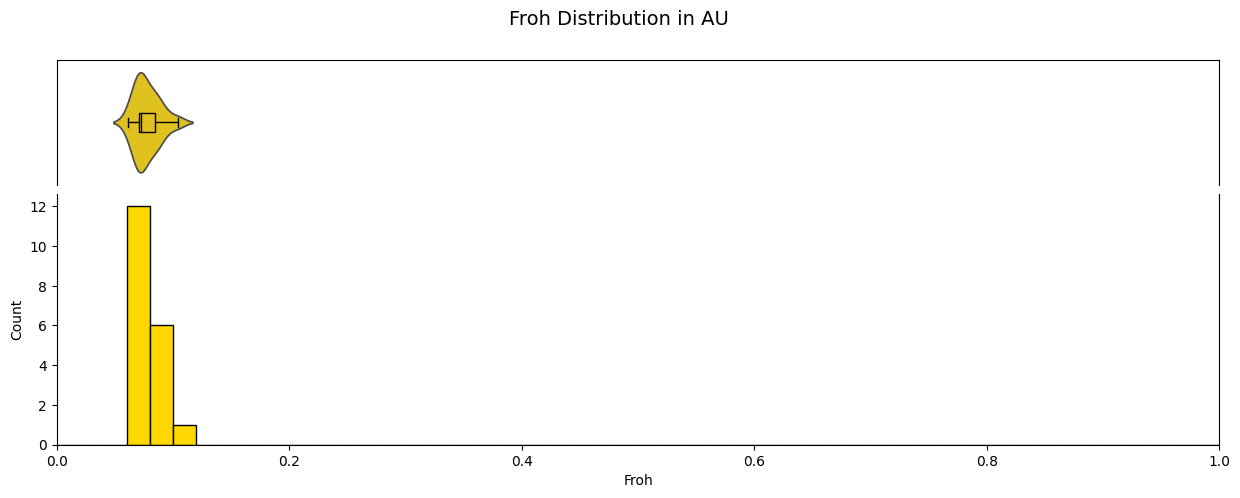

In [10]:
plot_easyFroh_distribution(roh_proportion, 'AU', color='gold', dpi=600, save_path='Git_Repos/2026_S_nereis_Cons_Gen/Figures/AU_ROH_distribution.png')

/tmp/ipykernel_5324/1193110868.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Figure saved: Git_Repos/2026_S_nereis_Cons_Gen/Figures/NZ_ROH_distribution.png


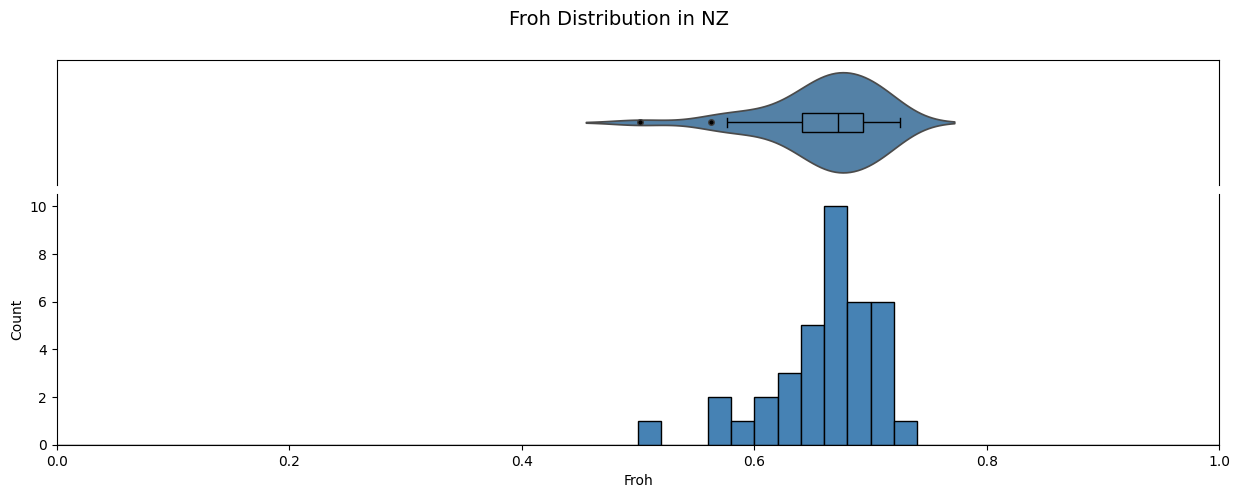

In [11]:
plot_easyFroh_distribution(roh_proportion, 'NZ', dpi=600, save_path='Git_Repos/2026_S_nereis_Cons_Gen/Figures/NZ_ROH_distribution.png')

/tmp/ipykernel_36138/1193110868.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Figure saved: Git_Repos/2026_S_nereis_Cons_Gen/Figures/KI_ROH_distribution.png


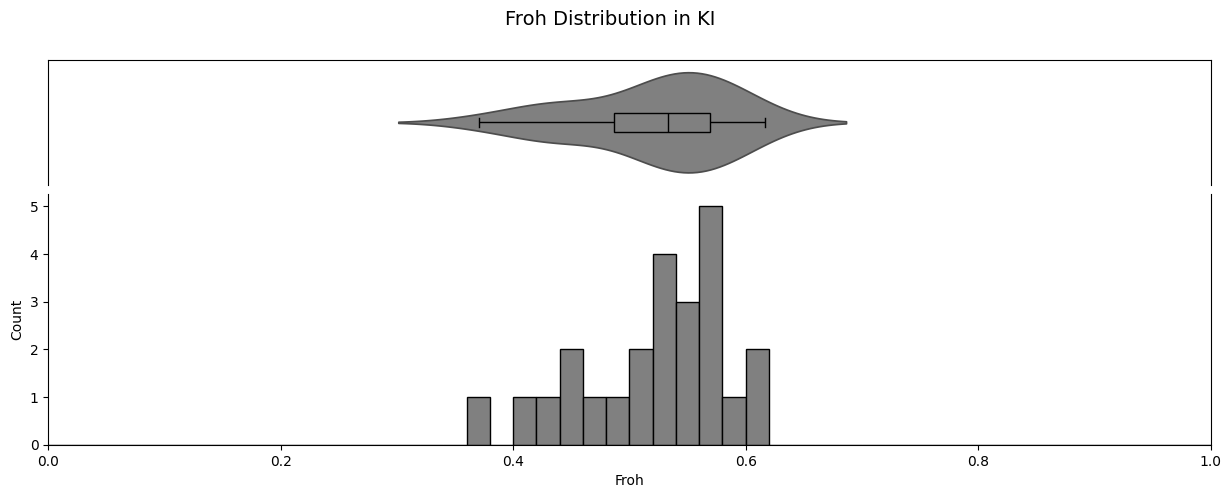

In [18]:
plot_easyFroh_distribution(roh_proportion, 'KI', color='grey', dpi=600, save_path='Git_Repos/2026_S_nereis_Cons_Gen/Figures/KI_ROH_distribution.png')

In [11]:
def compute_roh_bin_counts(df, bin_size=10_000):
    """
    Count ROH overlaps in fixed bins across all chromosomes.

    Parameters:
        df (pd.DataFrame): Input DataFrame with columns:
                           ['Chromosome', 'Start', 'End', 'Chromosome Size']
        bin_size (int): Bin size in base pairs (default: 10,000 bp)

    Returns:
        heatmap_df (pd.DataFrame): Long-format bin-level ROH counts
        chrom_sizes (pd.DataFrame): Chromosome sizes and cumulative starts
        chrom_order (list): Chromosomes ordered by size (descending)
    """
    df = df.copy()  # ✅ prevent SettingWithCopyWarning
    df['Chromosome Size'] = pd.to_numeric(df['Chromosome Size'], errors='coerce')
    
    chrom_sizes = df[['Chromosome', 'Chromosome Size']].drop_duplicates()
    chrom_order = chrom_sizes.sort_values('Chromosome Size', ascending=False)['Chromosome'].tolist()
    
    bin_counts = []

    for chrom in chrom_order:
        chrom_df = df[df['Chromosome'] == chrom]
        chrom_len = chrom_df['Chromosome Size'].iloc[0]
        num_bins = int(np.ceil(chrom_len / bin_size))
        bins = np.zeros(num_bins, dtype=int)

        for _, row in chrom_df.iterrows():
            start_bin = int(row['Start'] // bin_size)
            end_bin = int(row['End'] // bin_size)
            bins[start_bin:end_bin + 1] += 1

        bin_counts.extend([
            {'Chromosome': chrom, 'Bin': i, 'ROH Count': count}
            for i, count in enumerate(bins)
        ])

    heatmap_df = pd.DataFrame(bin_counts)
    return heatmap_df, chrom_sizes, chrom_order

In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

def plot_roh_horizontal_bar(heatmap_df, chrom_sizes, bin_size=50000, vmax=2, show_colorbar=True, title=None, figsize=(20,4)):
    """
    Plot ROH overlap density as a horizontal color bar across all chromosomes.

    Parameters:
        heatmap_df (pd.DataFrame): Output from compute_roh_bin_counts
        chrom_sizes (pd.DataFrame): Chromosome sizes
        bin_size (int): Bin size used in computation
        vmax (int): Maximum value for color scale
        show_colorbar (bool): Whether to display the color bar
        title (str): Optional title to display left-aligned, font size 18
        figsize :
    """
    # Compute cumulative start positions
    chrom_sizes = chrom_sizes.sort_values('Chromosome Size', ascending=False)
    chrom_sizes['Cumulative Start'] = chrom_sizes['Chromosome Size'].cumsum() - chrom_sizes['Chromosome Size']
    
    # Merge into bin dataframe and compute global position
    heatmap_df = heatmap_df.merge(chrom_sizes[['Chromosome', 'Cumulative Start']], on='Chromosome', how='left')
    heatmap_df['Global Position'] = heatmap_df['Cumulative Start'] + heatmap_df['Bin'] * bin_size + (bin_size // 2)
    
    # Sort by genome-wide position
    heatmap_df = heatmap_df.sort_values('Global Position')
    values = heatmap_df['ROH Count'].values
    norm = plt.Normalize(vmin=0, vmax=vmax)

    # Use BuPu colormap and map ROH values to colors
    cmap = plt.get_cmap('BuPu')
    colors = cmap(norm(values))

    # Plot
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow([colors], aspect='auto', extent=[0, heatmap_df['Global Position'].max(), 0, 1])

    # Draw chromosome boundaries
    for _, row in chrom_sizes.iterrows():
        ax.axvline(row['Cumulative Start'], color='black', linestyle='--', linewidth=2)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim([0, heatmap_df['Global Position'].max()])

    # Optional left-aligned title
    if title:
        ax.set_title(title, fontsize=20, loc='left', pad=20)

    # Optional colorbar
    if show_colorbar:
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])
        cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.2)
        cbar.set_label("ROH Density", fontsize=16)
        cbar.ax.tick_params(labelsize=16)

        # Set major ticks and ensure they're displayed
        ticks = np.linspace(0, vmax, num=6)
        cbar.set_ticks(ticks)
        cbar.ax.xaxis.set_major_locator(ticker.FixedLocator(ticks))
        cbar.ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x)}"))

    plt.tight_layout()


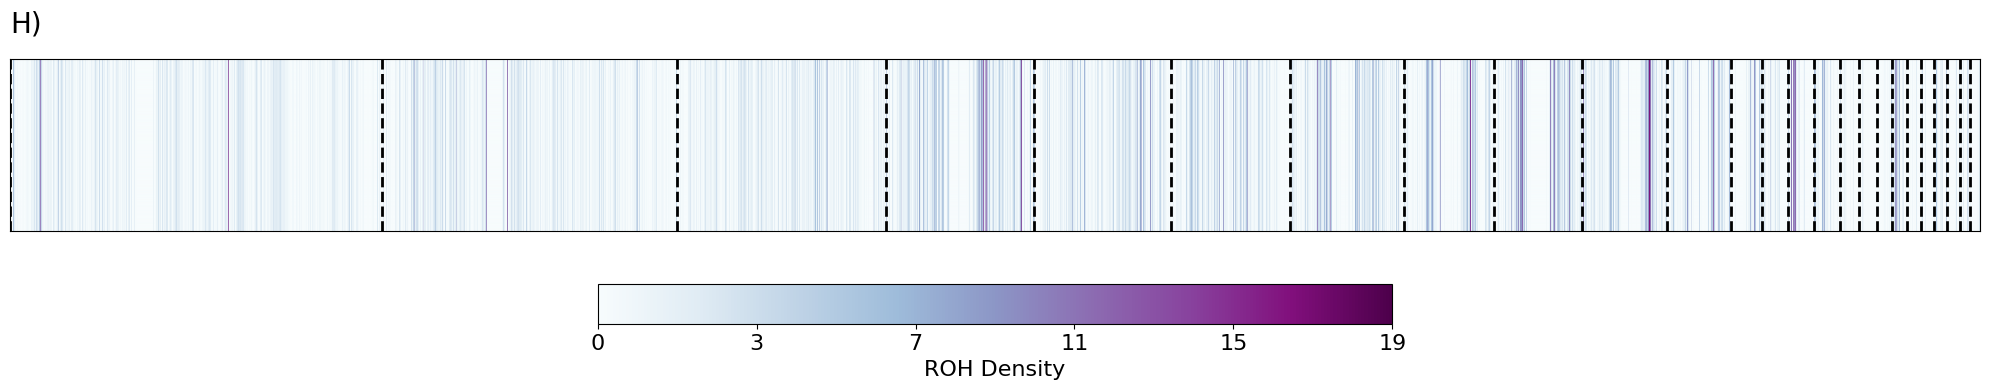

In [12]:
AU = roh[roh['Population']=='AU']

heatmap_df, chrom_sizes, chrom_order = compute_roh_bin_counts(AU, bin_size=1000)

plot_roh_horizontal_bar(heatmap_df, chrom_sizes, bin_size=1000, vmax=19, show_colorbar=True, figsize=(20,4), title='H)')

plt.savefig('Git_Repos/2026_S_nereis_Cons_Gen/Figures/Fig2_ROH_overlaps_AU.png', dpi=300, bbox_inches='tight')

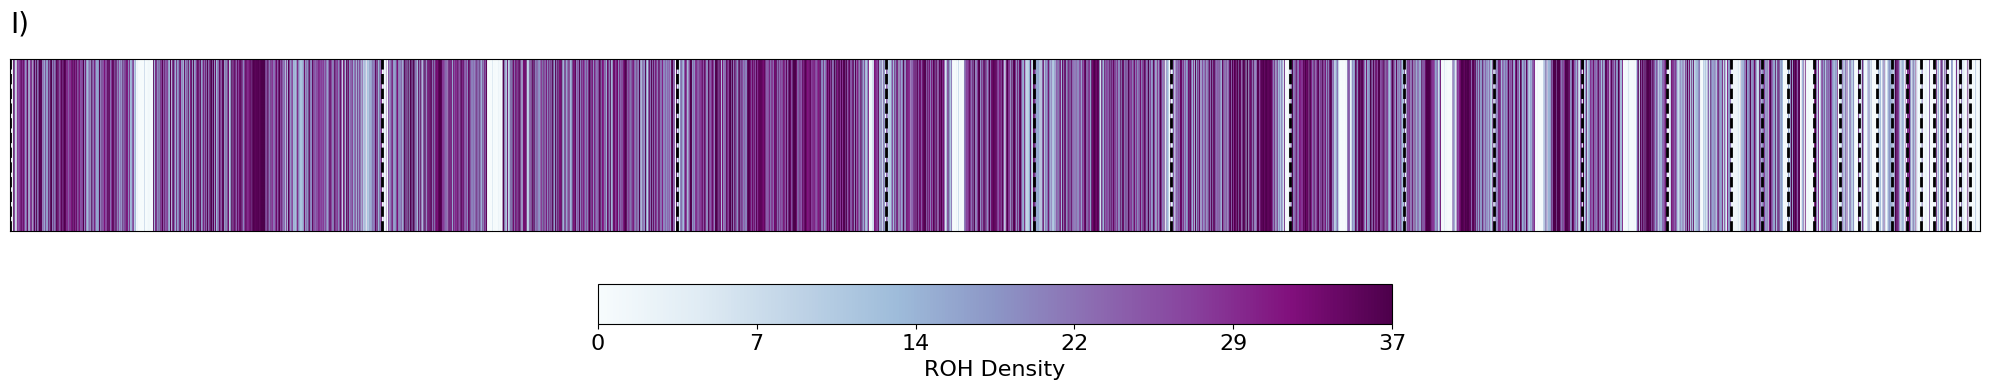

In [13]:
TI = roh[roh['Population']=='NZ']
heatmap_df, chrom_sizes, chrom_order = compute_roh_bin_counts(TI, bin_size=1000)

plot_roh_horizontal_bar(heatmap_df, chrom_sizes, bin_size=1000, vmax=37, show_colorbar=True, figsize=(20,4), title='I)')

plt.savefig('Git_Repos/2026_S_nereis_Cons_Gen/Figures/Fig2_ROH_overlaps_NZ.png', dpi=300, bbox_inches='tight')

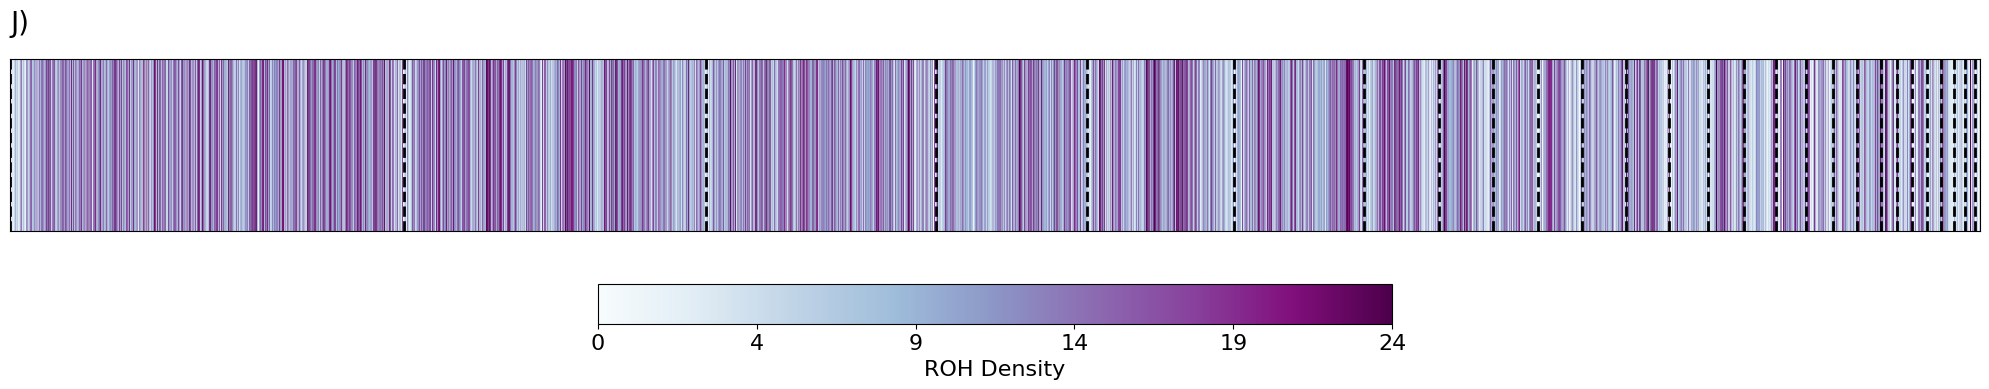

In [14]:
KI = roh[roh['Population']=='KI']
heatmap_df, chrom_sizes, chrom_order = compute_roh_bin_counts(KI, bin_size=1000)

plot_roh_horizontal_bar(heatmap_df, chrom_sizes, bin_size=1000, vmax=24, show_colorbar=True, figsize=(20,4), title='J)')

plt.savefig('Git_Repos/2026_S_nereis_Cons_Gen/Figures/Fig2_ROH_overlaps_KI.png', dpi=300, bbox_inches='tight')

### Individual Heterozygosity (H<sub>o</sub>)
#### SNPs
Here, we implemented a global (genome-wide heterozygosity) method from ANGSD. Essentially, this estimate is a proportion of heterozygous genotypes / genome size (excluding regions of the genome with low confidence). Unlike other runs of ANGSD, individual BAMs are used to estimate hetereozygosity, which is simply second value in the SFS/AFS.

In [ ]:
SAMP=$(sed -n "$((SLURM_ARRAY_TASK_ID + 1))p" /nesi/nobackup/uc03718/angsd/GLOBAL.list)
NAME=$(basename $SAMP _autosomes_nodup.bam)

printf "\nSTARTED RUNNING ANGSD TO ESTIMATE HETEROZYGOSITY FOR $NAME AT "
date

angsd -P 32 -i ${SAMP} -ref $TREF -out ${DIR}samtools/heterozygosity/${NAME} \
        -uniqueOnly 1 -remove_bads 1 -only_proper_pairs 1 -trim 0 -C 50 -angbaq 1 \
        -minMapQ 20 -minQ 20 -doCounts 1 -dosaf 1 -GL 1

realSFS ${DIR}samtools/heterozygosity/${NAME}.saf.ids > ${DIR}samtools/heterozygosity/${NAME}_est.ml

Once the SFS was estimated for each individual, the number of sites was estimated from the sum of all scaffold sizes included in the bam file and output to a file.  

In [ ]:
printf "Sample\tHomozygous Ref Sites\tHeterozygous Sites\tHomozygous Alt Sites\tPopulation\tDataset\n" > ${ANGSD}individual_het.tsv 

for POP in AU TI KI_10x KI
    do
    while read -r line
        do
        SAMP=$(echo $line)
        NEUTRAL_RR=$(awk '{print $1}' ${ANGSD}neutral/heterozygosity/${SAMP}_est.ml)
        NEUTRAL_RA=$(awk '{print $2}' ${ANGSD}neutral/heterozygosity/${SAMP}_est.ml)
        NEUTRAL_AA=$(awk '{print $3}' ${ANGSD}neutral/heterozygosity/${SAMP}_est.ml)
        WGENOME_RR=$(awk '{print $1}' ${ANGSD}samtools/heterozygosity/${SAMP}_est.ml)
        WGENOME_RA=$(awk '{print $2}' ${ANGSD}samtools/heterozygosity/${SAMP}_est.ml)
        WGENOME_AA=$(awk '{print $3}' ${ANGSD}samtools/heterozygosity/${SAMP}_est.ml)
        printf "$SAMP\t$NEUTRAL_RR\t$NEUTRAL_RA\t$NEUTRAL_AA\t${POP}\tneutral\n" >> individual_het.tsv
        printf "$SAMP\t$WGENOME_RR\t$WGENOME_RA\t$WGENOME_AA\t${POP}\twhole-genome\n" >> individual_het.tsv
    done < ${POP}_relatedness_IDs.txt
done

#### SVs
Genotypes for each individual were estimated and then plotted in 06_visualisations.ipynb.  

In [ ]:
while read -r line
    do
    REF=$(bcftools query -s ${line} -i 'GT!="mis" & GQ>=25 & GT=="RR"' -f '[%GT\n]' smoove/02_GLOBAL_filtered.bcf | wc -l)
    HET=$(bcftools query -s ${line} -i 'GT!="mis" & GQ>=25 & GT=="het"' -f '[%GT\n]' smoove/02_GLOBAL_filtered.bcf | wc -l)
    ALT=$(bcftools query -s ${line} -i 'GT!="mis" & GQ>=25 & GT=="AA"' -f '[%GT\n]' smoove/02_GLOBAL_filtered.bcf | wc -l)
    if [[ "$line" == "AU"* ]]
    then
        printf "$line\t$REF\t$HET\t$ALT\tAU GLOBAL\n"
        printf "$line\t$REF\t$HET\t$ALT\tAU GLOBAL\n" >> smoove/sv_het.tsv
    else
        printf "$line\t$REF\t$HET\t$ALT\tTI GLOBAL\n"
        printf "$line\t$REF\t$HET\t$ALT\tTI GLOBAL\n" >> smoove/sv_het.tsv
    fi
done < smoove/GLOBAL_pop.list

### SNP- and SV-based *H<sub>O</sub>* Estimates
The next diversity metric we examined was individual observed heterozygosity. SNPs were estimated using `ANGSD` and `realSFS` for all sites and putatively neutral sites where we excluded regions predicted to be coding regions by `AUGUSTUS`.  

We estimated structural variant heterozygosity as:
$$
H_{O} = \frac{\sum{H Sites}}{\sum{Genotyped Sites}}
$$

To examine the impact of read depth on SNPs and SVs, we leveraged the heterozygosity estimated using Australian fairy tern, tara iti, kakī subsampled alignments and high coverage kakī alignments. For esimtates of SV heterozygosity, we filtered out all invariant sites in the Australian fairy tern and tara iti populations. This included fixed SVs in Australian fairy terns.   

In [19]:
sv_het = pd.read_csv('smoove/sv_het.tsv', delimiter='\t')
excluded_samples =[
    'TI102', 'TI89', 'TI62',
    'TI65', 'TI82', 'TI83',
    'TI88', 'TI90', 'TI98', 
    'TI94', 'TI64', 'TI66', 'TI86',
    'TI100', 'TI52', 'TI70', 'TI87'
    ]

sv_het = sv_het[~sv_het['Sample'].isin(exclude)]

sv_het.tail()

,Sample,Homozygous Reference,Heterozygous,Homozygous Alternate,Population,Dataset
131,H01402,1171,674,354,KI,private
132,H01403,1200,697,302,KI,private
133,H01404,1290,739,170,KI,private
134,H01405,1308,606,285,KI,private
135,H01406,1095,782,322,KI,private


### Kakī SV Mendelian Inheritance
Here we examine the number of sites adhering to mendelian inheritance expectations in X trios for 3 data sets filtered for genotyping quality:
1) SVs discovered and genotyped using high coverage data
2) SVs discovered using high coverage data, and genotyped using subset data
3) SVs discovered and genotyped using subset data

Here, high coverage data is ranging from ~22x - ~67x alignment depth while subset data represents aligned depths ranging from ~6x = ~13x.  

In [ ]:
kiSVmendel = pd.read_csv('graphtyper/graphtyper_kaki_subset/KI_mendelian_counts.tsv', sep='\t')

kiSVmendel.head()

In [ ]:
kiSVmendel.groupby(['Data set'])['Percent Failing'].mean().reset_index()

Here, we are briefly examining the average proportion of SVs in either a homozygous reference or alternate state in Australian fairy tern, tara iti, and subsampled kakī data sets.  

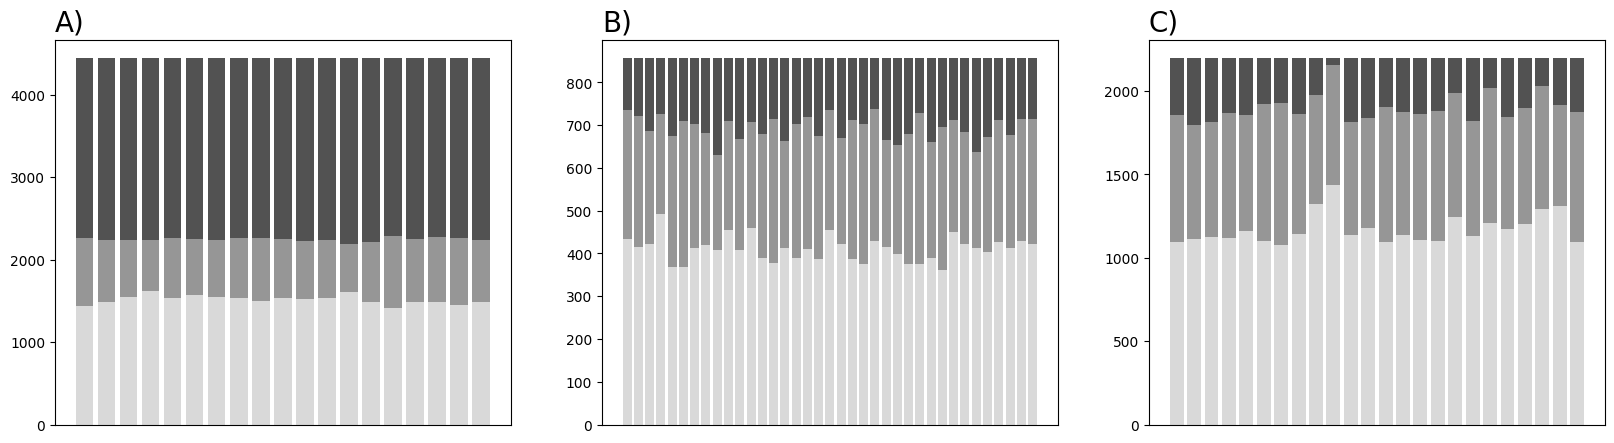

In [16]:
sv_het = pd.read_csv('smoove/sv_het.tsv', delimiter='\t')
excluded_samples =['TI102', 'TI89', 'TI62', 'TI65', 'TI82', 'TI83', 'TI88', 'TI90', 'TI98', 'TI94', 'TI64', 'TI66', 'TI86', 'TI100', 'TI52', 'TI70', 'TI87']
sv_het = sv_het[~sv_het['Sample'].isin(excluded_samples)]

sv_het.tail()

# Grayscale colors for the three categories
colors = ['#d9d9d9', '#969696', '#525252']  # Light, medium, and dark gray

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharex=False, sharey=False)  

sv_het = sv_het[sv_het['Dataset']=='private']
au_svHet = sv_het[sv_het['Population'] == 'AU']  # Filter for the target population and data set
ti_svHet = sv_het[sv_het['Population'] == 'NZ']
ki_svHet = sv_het[sv_het['Population'] == 'KI']
aux = np.arange(len(au_svHet))
tix = np.arange(len(ti_svHet))
kix = np.arange(len(ki_svHet))

# Plot stacked bars
axes[0].bar(aux, au_svHet['Homozygous Reference'], label='Homozygous Reference', color=colors[0])
axes[0].bar(aux, au_svHet['Heterozygous'], bottom=au_svHet['Homozygous Reference'], label='Heterozygous', color=colors[1])
axes[0].bar(aux, au_svHet['Homozygous Alternate'], bottom=au_svHet['Homozygous Reference'] + au_svHet['Heterozygous'], label='Homozygous Alt', color=colors[2])
axes[0].set_xticks([])
axes[0].set_title('A)', fontsize = 20, loc='left')
#axes[0].set_ylim(0,1800)

axes[1].bar(tix, ti_svHet['Homozygous Reference'], label='Homozygous Reference', color=colors[0])
axes[1].bar(tix, ti_svHet['Heterozygous'], bottom=ti_svHet['Homozygous Reference'], label='Heterozygous', color=colors[1])
axes[1].bar(tix, ti_svHet['Homozygous Alternate'], bottom=ti_svHet['Homozygous Reference'] + ti_svHet['Heterozygous'], label='Homozygous Alternate', color=colors[2])
axes[1].set_xticks([])
axes[1].set_title('B)', fontsize = 20, loc='left')
#axes[1].set_ylim(0,1800)

axes[2].bar(kix, ki_svHet['Homozygous Reference'], label='Homozygous Reference', color=colors[0])
axes[2].bar(kix, ki_svHet['Heterozygous'], bottom=ki_svHet['Homozygous Reference'], label='Heterozygous', color=colors[1])
axes[2].bar(kix, ki_svHet['Homozygous Alternate'], bottom=ki_svHet['Homozygous Reference'] + ki_svHet['Heterozygous'], label='Homozygous Alternate', color=colors[2])
axes[2].set_xticks([])
axes[2].set_title('C)', fontsize = 20, loc='left')
#axes[2].set_ylim(0,1800)

plt.savefig('Git_Repos/2026_S_nereis_Cons_Gen/Figures/Supplemental_SV_geno_proportions.png', dpi=300, bbox_inches='tight')

In [ ]:
kiSVmendel = kiSVmendel[kiSVmendel['Data set']!='50xSVs_10xGenotypes']

order = ['10xSVs_10xGenotypes', '50xSVs_50xGenotypes']

plt.figure(figsize=(10, 5))

sns.violinplot(data=kiSVmendel, x='Data set', y='Percent Failing', color='0.8', order=order)
sns.stripplot(data=kiSVmendel, x='Data set', y='Percent Failing', jitter=True, color='black', order=order)
plt.xticks(['10xSVs_10xGenotypes', '50xSVs_50xGenotypes'], ['KĪ low', 'KĪ high'], fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(0, 18)
plt.ylabel('Percent Failing Sites', fontsize = 18)
plt.xlabel('')
plt.title('E)', fontsize = 20, loc='left')

plt.savefig('TI_ms_plots/Figure_2b.pdf', dpi=300, bbox_inches='tight')

Here, we are briefly examining the average proportion of SVs in either a homozygous reference or alternate state in Australian fairy tern, tara iti, and subsampled kakī data sets.  

In [23]:
sv_het = pd.read_csv('smoove/sv_het.tsv', delimiter='\t')
excluded_samples =['TI102', 'TI89', 'TI62', 'TI65', 'TI82', 'TI83', 'TI88', 'TI90', 'TI98', 'TI94', 'TI64', 'TI66', 'TI86', 'TI100', 'TI52', 'TI70', 'TI87']
sv_het = sv_het[~sv_het['Sample'].isin(excluded_samples)]

sv_het['Total'] = sv_het['Homozygous Reference'] + sv_het['Heterozygous'] + sv_het['Homozygous Alternate']
sv_het['Proportion Ref'] = sv_het['Homozygous Reference'] / sv_het['Total']
sv_het['Proportion Het'] = sv_het['Heterozygous'] / sv_het['Total']
sv_het['Proportion Alt'] = sv_het['Homozygous Alternate'] / sv_het['Total']

print("Mean proportion of homozygous alternate sites in AFT: ", sv_het[sv_het['Population']=='AU']['Proportion Alt'].mean())
print("Mean proportion of homozygous alternate sites in TI: ", sv_het[sv_het['Population']=='TI']['Proportion Alt'].mean())
print("Mean proportion of homozygous alternate sites in KI: ", sv_het[sv_het['Population']=='KI']['Proportion Alt'].mean())

print("Mean proportion of homozygous reference sites in AFT: ", sv_het[sv_het['Population']=='AU']['Proportion Ref'].mean())
print("Mean proportion of homozygous reference sites in TI: ", sv_het[sv_het['Population']=='TI']['Proportion Ref'].mean())
print("Mean proportion of homozygous reference sites in KI: ", sv_het[sv_het['Population']=='KI']['Proportion Ref'].mean())

Mean proportion of homozygous alternate sites in AFT:  0.47217485814754295
Mean proportion of homozygous alternate sites in TI:  nan
Mean proportion of homozygous alternate sites in KI:  0.1362930119751402
Mean proportion of homozygous reference sites in AFT:  0.36771023571228545
Mean proportion of homozygous reference sites in TI:  nan
Mean proportion of homozygous reference sites in KI:  0.5321737153251478


In [24]:
indiv_het = pd.read_csv('angsd/individual_het.tsv', delimiter='\t')
excluded_samples =['TI102', 'TI89', 'TI62', 'TI65', 'TI82', 'TI83', 'TI88', 'TI90', 'TI98', 'TI94', 'TI64', 'TI66', 'TI86', 'TI100', 'TI52', 'TI70', 'TI87']
indiv_het = indiv_het[~indiv_het['Sample'].isin(excluded_samples)]

indiv_het = indiv_het.sort_values(by=['Sample', 'Population'], ascending=[True, True])
indiv_het['Heterozygosity'] = indiv_het['Heterozygous Sites'] / (indiv_het['Homozygous Ref Sites'] + indiv_het['Heterozygous Sites'] + indiv_het['Homozygous Alt Sites'] )
neutral_het = indiv_het[indiv_het['Dataset'] == 'neutral']

neutral_het.head()

,Sample,Homozygous Ref Sites,Heterozygous Sites,Homozygous Alt Sites,Population,Dataset,Heterozygosity
0,AU01,5.546062e+08,263594.796810,1.170285e+07,AU,neutral,0.000465
2,AU03,5.534277e+08,234043.744266,1.164816e+07,AU,neutral,0.000414
4,AU04,5.513811e+08,225557.382068,1.155151e+07,AU,neutral,0.000401
6,AU06,5.502594e+08,194723.440327,1.152173e+07,AU,neutral,0.000346
8,AU08,5.517146e+08,223312.949336,1.157205e+07,AU,neutral,0.000396


For relative comparisons of diversity, examined individual heterozygosity for SNPs (A) in Australian fairy tern, tara iti and high coverage kakī data sets, and SVs (B) jointly called and genotyped in fairy terns (i.e., including sites fixed in either population), as well as individual ROH counts (C) and ROH proportions (D) for all three groups.  

In [25]:
neutral_het.tail()

,Sample,Homozygous Ref Sites,Heterozygous Sites,Homozygous Alt Sites,Population,Dataset,Heterozygosity
132,TI93,5.688756e+08,58415.303121,1.248178e+07,NZ,neutral,0.000100
136,TI95,5.676111e+08,56867.328473,1.242076e+07,NZ,neutral,0.000098
138,TI96,5.694877e+08,61444.276373,1.251298e+07,NZ,neutral,0.000106
140,TI97,5.679411e+08,57875.685026,1.243382e+07,NZ,neutral,0.000100
144,TI99,5.700556e+08,71735.624669,1.253719e+07,NZ,neutral,0.000123


In [3]:
indiv_het = pd.read_csv('angsd/individual_het.tsv', delimiter='\t')
excluded_samples =['TI102', 'TI89', 'TI62', 'TI65', 'TI82', 'TI83', 'TI88', 'TI90', 'TI98', 'TI94', 'TI64', 'TI66', 'TI86', 'TI100', 'TI52', 'TI70', 'TI87']
indiv_het = indiv_het[~indiv_het['Sample'].isin(excluded_samples)]
indiv_het = indiv_het.sort_values(by=['Sample', 'Population'], ascending=[True, True])
indiv_het['Heterozygosity'] = indiv_het['Heterozygous Sites'] / (indiv_het['Homozygous Ref Sites'] + indiv_het['Heterozygous Sites'] + indiv_het['Homozygous Alt Sites'])
neutral_het = indiv_het[indiv_het['Dataset'] == 'neutral']

sv_het = pd.read_csv('smoove/sv_het.tsv', delimiter='\t')
sv_het = sv_het[~sv_het['Sample'].isin(excluded_samples)]
sv_het['Heterozygosity'] = sv_het['Heterozygous'] / (sv_het['Homozygous Reference'] + sv_het['Heterozygous'] + sv_het['Homozygous Alternate'])

sv_fairyhet = sv_het[sv_het['Dataset'] == 'Global']
sv_var_het = sv_het[sv_het['Dataset'] == 'private']

roh = pd.read_csv('rohan/ROHs.tsv', sep='\t')
roh_segments = pd.read_csv('rohan/ROH_segment_summary.txt', sep='\t')
roh = roh[~roh['Sample'].isin(excluded_samples)]

roh_summary = roh[['Sample', 'Size Class', 'Population']]
roh_summary = roh_summary.groupby(['Sample', 'Size Class', 'Population']).size().reset_index(name='ROH Counts')
roh_summary = roh_summary.sort_values('Size Class', ascending=False)

roh_len = roh[['Sample', 'ROH Length', 'Size Class', 'Population']]
roh_len = roh_len.groupby(['Sample', 'Size Class', 'Population'])['ROH Length'].sum().reset_index(name='ROH Total')

roh_segments['Total Segments Included'] = roh_segments['Segments in ROH'] + roh_segments['Segments in non-ROH']

roh_len = roh_len.merge(roh_segments[['Sample', 'Total Segments Included']], on='Sample', how='left')

roh_len['Proportion'] = roh_len['ROH Total'] / roh_len['Total Segments Included']

roh_len = roh_len.sort_values('Size Class', ascending=False)

/tmp/ipykernel_5324/2223772879.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['AFT', 'NZ', 'KĪ'], fontsize=22, rotation=45)
/tmp/ipykernel_5324/2223772879.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['AFT', 'NZ', 'KĪ'], fontsize=20, rotation=45)


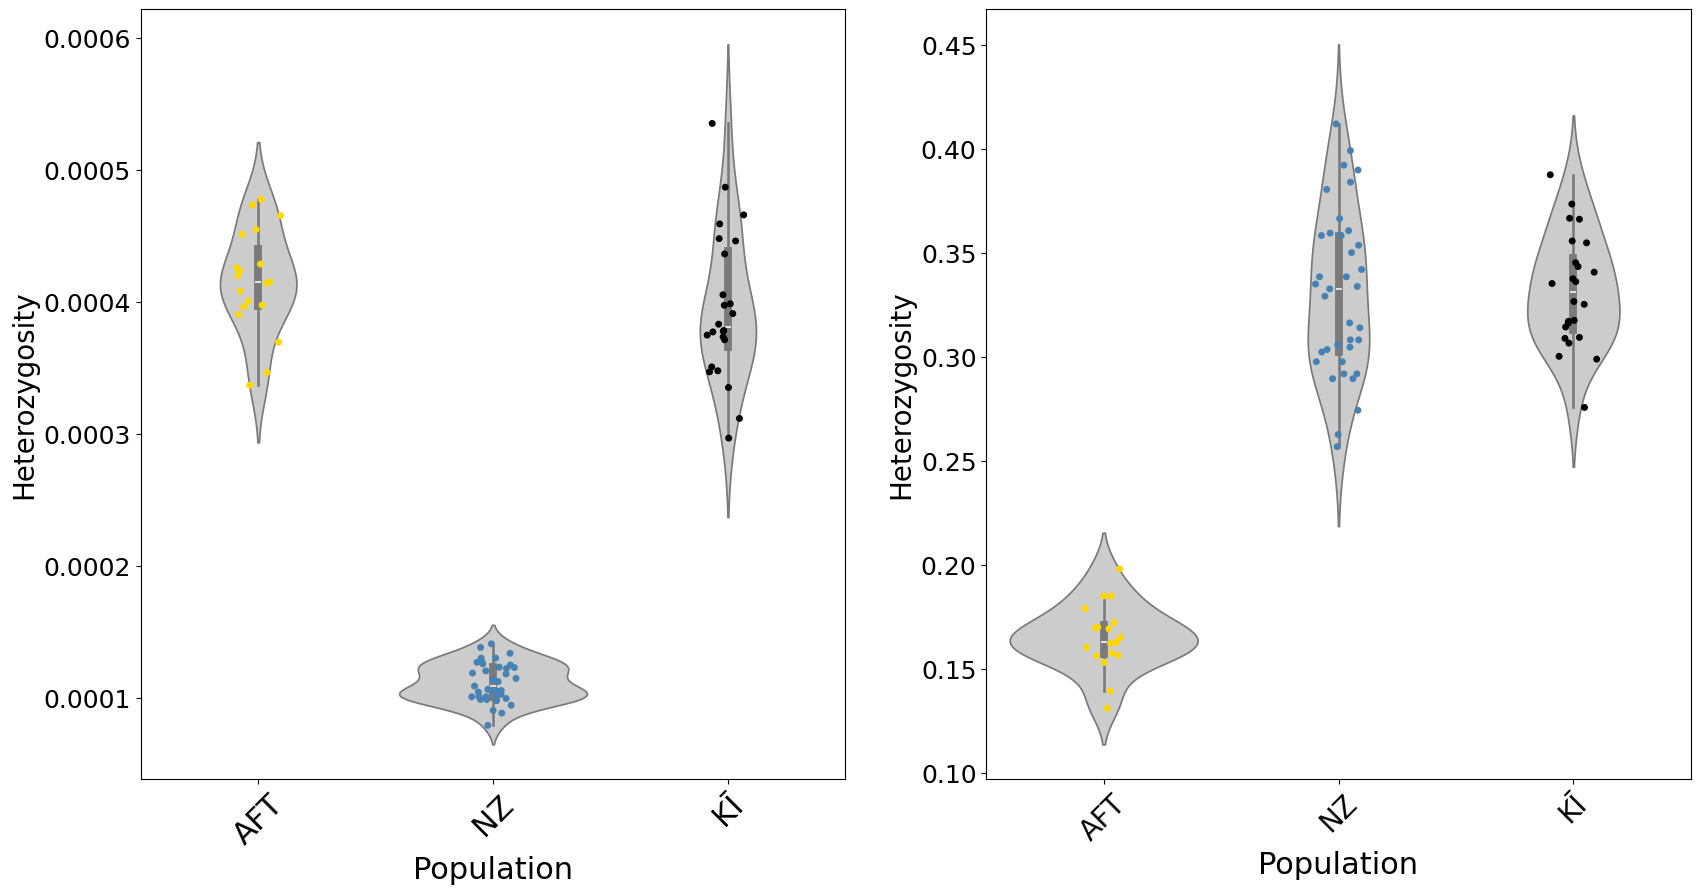

In [28]:
xvalues = ["Short ROHs", "Medium ROHs", "Long ROHs"]
palette = ['gold', 'steelblue', 'black']
order = ['AU', 'NZ', 'KI']

fig, axes = plt.subplots(1, 2, figsize=(20, 10), sharex=False, sharey=False)

# SNP heterozygosity
sns.violinplot(data = neutral_het[neutral_het['Population']!='KI_10x'], x = "Population", y = "Heterozygosity", order=order, color="0.8", ax=axes[0])
sns.stripplot(data = neutral_het[neutral_het['Population']!='KI_10x'], x = "Population", y = "Heterozygosity", hue = "Population", hue_order=order, palette=palette, jitter = True, size=5, ax=axes[0])
axes[0].set_xticklabels(['AFT', 'NZ', 'KĪ'], fontsize=22, rotation=45)
axes[0].set_xlabel('Population', fontsize=22)
axes[0].set_ylabel("Heterozygosity", fontsize=20)
axes[0].tick_params(axis='y', which='major', labelsize=18)

# Variable SV heterozygosity
sns.violinplot(data = sv_var_het, x = 'Population', y = 'Heterozygosity', color='0.8', ax=axes[1])
sns.stripplot(data = sv_var_het, x = 'Population', y = 'Heterozygosity', hue = 'Population', palette=palette, jitter = True, size=5, ax=axes[1])
axes[1].set_xticklabels(['AFT', 'NZ', 'KĪ'], fontsize=20, rotation=45)
axes[1].set_xlabel('Population', fontsize=22)
axes[1].set_ylabel('Heterozygosity', fontsize=20)
axes[1].tick_params(axis='y', which='major', labelsize=18)

plt.savefig('Git_Repos/2026_S_nereis_Cons_Gen/Figures/HET_comparisons.png', dpi=300, bbox_inches='tight')

/tmp/ipykernel_5324/2895314841.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Short', 'Medium', 'Large'], fontsize=20)
/tmp/ipykernel_5324/2895314841.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Short', 'Medium', 'Large'], fontsize=22)
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Fall

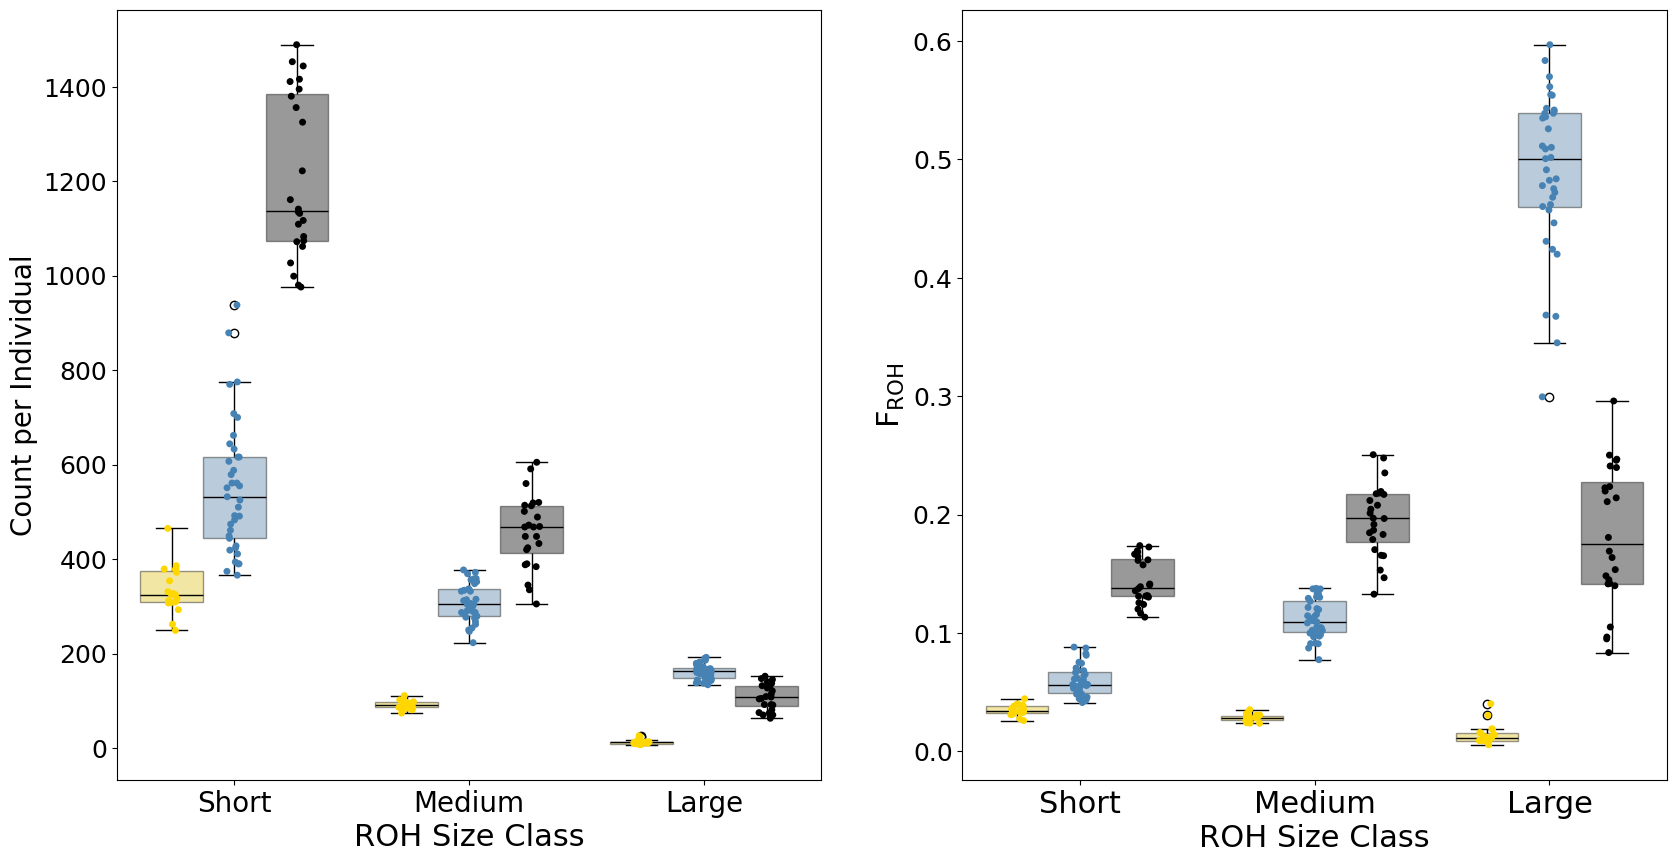

In [29]:
xvalues = ["Short ROHs", "Medium ROHs", "Long ROHs"]
palette = ['gold', 'steelblue', 'grey', 'black']
palette = ['gold', 'steelblue', 'black']
order = ['AU', 'NZ', 'KI']

fig, axes = plt.subplots(1, 2, figsize=(20, 10), sharex=False, sharey=False)

# ROH Count
sns.boxplot(data=roh_summary, x="Size Class", y="ROH Counts", hue="Population", palette=palette, hue_order=order, boxprops={'alpha': 0.4},ax=axes[0], legend=False)
sns.stripplot(data=roh_summary, x="Size Class", y="ROH Counts", hue="Population", palette=palette, hue_order=order, dodge=True, ax=axes[0], legend=False)
#axes[0].set_title('D)', loc='left', fontsize=42)
axes[0].set_xticklabels(['Short', 'Medium', 'Large'], fontsize=20)
axes[0].set_xlabel('ROH Size Class', fontsize=22)
axes[0].set_ylabel("Count per Individual", fontsize=20)
axes[0].tick_params(axis='y', which='major', labelsize=18)

# ROH Proportion
sns.boxplot(data=roh_len, x="Size Class", y="Proportion", hue="Population", palette=palette, hue_order=order, boxprops={'alpha': 0.4}, ax=axes[1], legend=False)
sns.stripplot(data=roh_len, x="Size Class", y="Proportion", hue="Population", palette=palette, hue_order=order, dodge=True, ax=axes[1], legend=False)
#axes[1].set_title('E)', loc='left', fontsize=42)
axes[1].set_xticklabels(['Short', 'Medium', 'Large'], fontsize=22)
axes[1].set_xlabel('ROH Size Class', fontsize=22)
axes[1].set_ylabel("$F_{ROH}$", fontsize=22)
axes[1].tick_params(axis='y', which='major', labelsize=18)

plt.savefig('Git_Repos/2026_S_nereis_Cons_Gen/Figures/ROH_comparisons.png', dpi=300, bbox_inches='tight')

/tmp/ipykernel_2783/376548584.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['AFT', 'NZ', 'KĪ'], fontsize=22, rotation=45)
/tmp/ipykernel_2783/376548584.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['AFT', 'NZ', 'KĪ'], fontsize=20, rotation=45)
/tmp/ipykernel_2783/376548584.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(['Short', 'Medium', 'Large'], fontsize=20)
/tmp/ipykernel_2783/376548584.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[3].set_xticklabels(['Short', 'Medium', 'Large'], fontsize=22)
findfont: Font family ['STIXGeneral'] not found. Falling

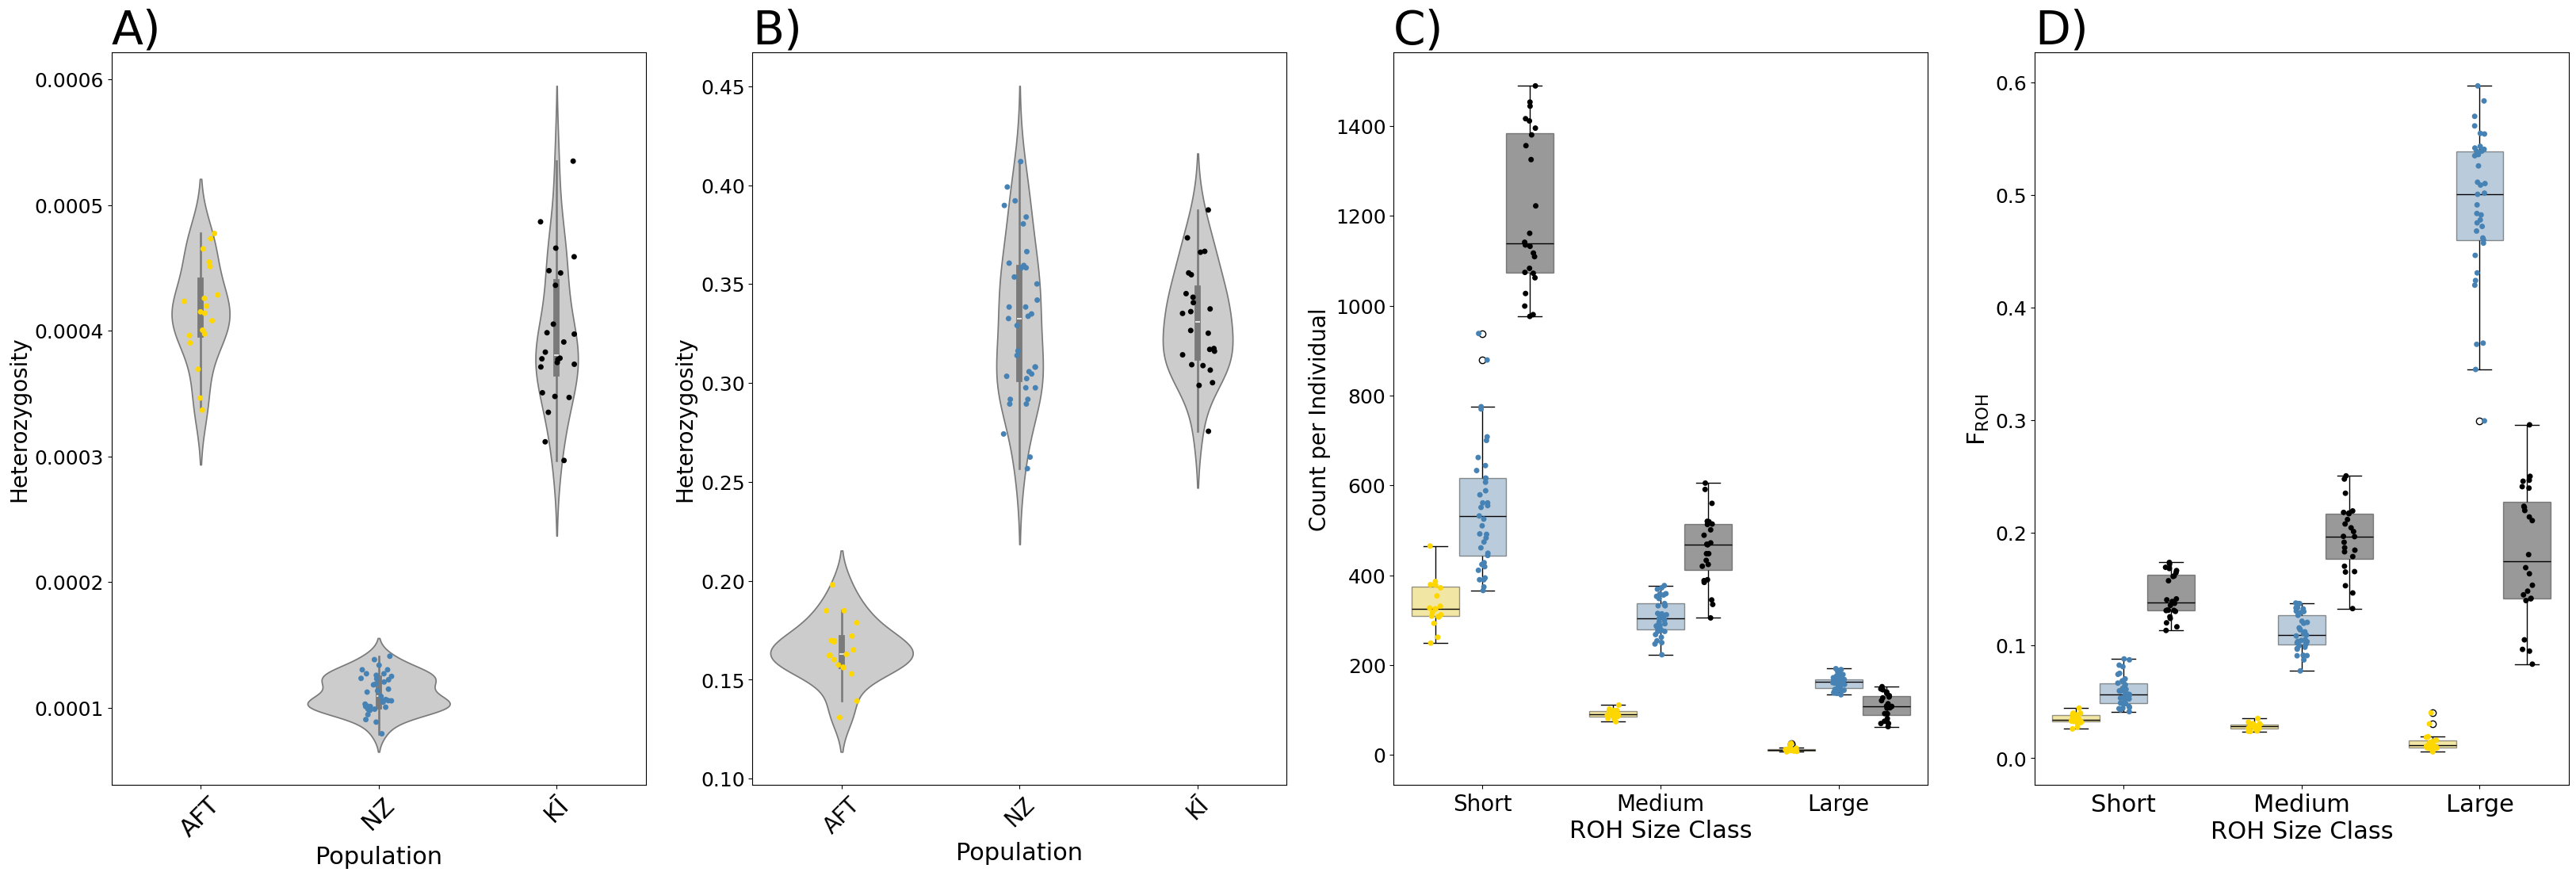

In [4]:
xvalues = ["Short ROHs", "Medium ROHs", "Long ROHs"]
palette = ['gold', 'steelblue', 'grey', 'black']
palette = ['gold', 'steelblue', 'black']
order = ['AU', 'NZ', 'KI']

fig, axes = plt.subplots(1, 4, figsize=(40, 12), sharex=False, sharey=False)

# SNP heterozygosity
sns.violinplot(data = neutral_het[neutral_het['Population']!='KI_10x'], x = "Population", y = "Heterozygosity", order=order, color="0.8", ax=axes[0])
sns.stripplot(data = neutral_het[neutral_het['Population']!='KI_10x'], x = "Population", y = "Heterozygosity", hue = "Population", hue_order=order, palette=palette, jitter = True, size=5, ax=axes[0])
axes[0].set_title('A)', loc='left', fontsize=42)
axes[0].set_xticklabels(['AFT', 'NZ', 'KĪ'], fontsize=22, rotation=45)
axes[0].set_xlabel('Population', fontsize=22)
axes[0].set_ylabel("Heterozygosity", fontsize=20)
axes[0].tick_params(axis='y', which='major', labelsize=18)

# Variable SV heterozygosity
sns.violinplot(data = sv_var_het, x = 'Population', y = 'Heterozygosity', color='0.8', ax=axes[1])
sns.stripplot(data = sv_var_het, x = 'Population', y = 'Heterozygosity', hue = 'Population', palette=palette, jitter = True, size=5, ax=axes[1])
axes[1].set_title('B)', loc='left', fontsize=42)
axes[1].set_xticklabels(['AFT', 'NZ', 'KĪ'], fontsize=20, rotation=45)
axes[1].set_xlabel('Population', fontsize=22)
axes[1].set_ylabel('Heterozygosity', fontsize=20)
axes[1].tick_params(axis='y', which='major', labelsize=18)

# ROH Count
sns.boxplot(data=roh_summary, x="Size Class", y="ROH Counts", hue="Population", palette=palette, hue_order=order, boxprops={'alpha': 0.4},ax=axes[2], legend=False)
sns.stripplot(data=roh_summary, x="Size Class", y="ROH Counts", hue="Population", palette=palette, hue_order=order, dodge=True, ax=axes[2], legend=False)
axes[2].set_title('C)', loc='left', fontsize=42)
axes[2].set_xticklabels(['Short', 'Medium', 'Large'], fontsize=20)
axes[2].set_xlabel('ROH Size Class', fontsize=22)
axes[2].set_ylabel("Count per Individual", fontsize=20)
axes[2].tick_params(axis='y', which='major', labelsize=18)

# ROH Proportion
sns.boxplot(data=roh_len, x="Size Class", y="Proportion", hue="Population", palette=palette, hue_order=order, boxprops={'alpha': 0.4}, ax=axes[3], legend=False)
sns.stripplot(data=roh_len, x="Size Class", y="Proportion", hue="Population", palette=palette, hue_order=order, dodge=True, ax=axes[3], legend=False)
axes[3].set_title('D)', loc='left', fontsize=42)
axes[3].set_xticklabels(['Short', 'Medium', 'Large'], fontsize=22)
axes[3].set_xlabel('ROH Size Class', fontsize=22)
axes[3].set_ylabel("$F_{ROH}$", fontsize=22)
axes[3].tick_params(axis='y', which='major', labelsize=18)

plt.savefig('Git_Repos/2026_S_nereis_Cons_Gen/Figures/Fig2_het_ROH_len.png', dpi=300, bbox_inches='tight')

Significance of differences in individual heterozygosity.  

In [31]:
def mann_whitney_test(df, group_col, value_col, group1, group2):
    group1_values = df[df[group_col] == group1][value_col]
    group2_values = df[df[group_col] == group2][value_col]
    stat, p_value = mannwhitneyu(group1_values, group2_values, alternative='two-sided')
    return stat, p_value

groups = ['AU', 'NZ', 'KI']
results_total = {}

for i in range(len(groups)):
    for j in range(i + 1, len(groups)):
        group1 = groups[i]
        group2 = groups[j]
        stat, p_value = mann_whitney_test(neutral_het, 'Population', 'Heterozygosity', group1, group2)
        results_total[f'{group1} vs {group2}'] = {'stat': stat, 'p_value': p_value}

# Print the results
print("Mann-Whitney U Test results for SNP heterozygosity:")
for comparison, result in results_total.items():
    print(f"{comparison}: U-statistic = {result['stat']}, p-value = {result['p_value']}")

for i in range(len(groups)):
    standard_dev = neutral_het[neutral_het['Population']==groups[i]]['Heterozygosity'].std()
    count = neutral_het[neutral_het['Population']==groups[i]]['Heterozygosity'].count()
    standard_err = standard_dev / np.sqrt(count)
    print(f"Mean individual SNP heterozygosity for {groups[i]}: {neutral_het[neutral_het['Population']==groups[i]]['Heterozygosity'].mean()} +/- {standard_err}")

Mann-Whitney U Test results for SNP heterozygosity:
AU vs NZ: U-statistic = 703.0, p-value = 1.2467728339679515e-09
AU vs KI: U-statistic = 294.0, p-value = 0.10918770820305677
NZ vs KI: U-statistic = 0.0, p-value = 5.847037048401915e-11
Mean individual SNP heterozygosity for AU: 0.00041549639892401075 +/- 8.966503139730254e-06
Mean individual SNP heterozygosity for NZ: 0.00011186504918406149 +/- 2.4330963923884236e-06
Mean individual SNP heterozygosity for KI: 0.0003955783265977146 +/- 1.15393108437803e-05


In [32]:
sv_het[sv_het['Population']!='AU'].head()

,Sample,Homozygous Reference,Heterozygous,Homozygous Alternate,Population,Dataset,Heterozygosity
38,SND04,4413,308,120,NZ,global,0.063623
39,SND06,4373,334,134,NZ,global,0.068994
40,SND11,4379,290,172,NZ,global,0.059905
41,SP02,4465,247,129,NZ,global,0.051023
42,SP03,4334,325,182,NZ,global,0.067135


In [33]:
sv_het = pd.read_csv('smoove/sv_het.tsv', delimiter='\t')
excluded_samples =['TI102', 'TI89', 'TI62', 'TI65', 'TI82', 'TI83', 'TI88', 'TI90', 'TI98', 'TI94', 'TI64', 'TI66', 'TI86', 'TI100', 'TI52', 'TI70', 'TI87']
sv_het = sv_het[~sv_het['Sample'].isin(excluded_samples)]
sv_het['Heterozygosity'] = sv_het['Heterozygous'] / (sv_het['Homozygous Alternate'] + sv_het['Heterozygous'] + sv_het['Homozygous Reference'])

def mann_whitney_test(df, group_col, value_col, group1, group2):
    group1_values = df[df[group_col] == group1][value_col]
    group2_values = df[df[group_col] == group2][value_col]
    stat, p_value = mannwhitneyu(group1_values, group2_values, alternative='two-sided')
    return stat, p_value

groups = ['AU', 'NZ', 'KI']
results_total = {}

# Loop through each SV callset
for dataset in sv_het['Dataset'].unique():
    df_subset = sv_het[sv_het['Dataset'] == dataset]
    results_total[dataset] = {}

    populations = df_subset['Population'].dropna().unique()

    # Now for pairwise group comparisons
    for i in range(len(populations)):
        for j in range(i + 1, len(populations)):
            group1, group2 = populations[i], populations[j]
            stat, p_value = mann_whitney_test(df_subset, 'Population', 'Heterozygosity', group1, group2)
            results_total[dataset][f'{group1} vs {group2}'] = {'stat': stat, 'p_value': p_value}

print("Mann–Whitney U Test results for SV heterozygosity:")
for dataset, comparisons in results_total.items():
    print(f"\nDataset: {dataset}")
    if not comparisons:
        print(" (No valid group comparisons found)")
    for comparison, result in comparisons.items():
        print(f"  {comparison}: U-statistic = {result['stat']}, p-value = {result['p_value']}")

# Loop through each dataset
for dataset in sv_het['Dataset'].unique():
    df_subset = sv_het[sv_het['Dataset'] == dataset]
    populations = df_subset['Population'].dropna().unique()
    
    print(f"\nAdditional summary statistics for dataset: {dataset}")
    
    for pop in populations:
        subset = df_subset[df_subset['Population'] == pop]['Heterozygosity'].dropna()
        mean_val = subset.mean()
        std_val = subset.std()
        count = subset.count()
        standard_err = std_val / np.sqrt(count) if count > 0 else np.nan
        
        print(f"  {pop}: mean = {mean_val:.4f}, std = {std_val:.4f}, SE = {standard_err:.4f} (n={count})")

Mann–Whitney U Test results for SV heterozygosity:

Dataset: private
  AU vs NZ: U-statistic = 0.0, p-value = 1.241139965456727e-09
  AU vs KI: U-statistic = 0.0, p-value = 2.638044719210391e-08
  NZ vs KI: U-statistic = 413.0, p-value = 0.6524787096901661

Dataset: global
  AU vs NZ: U-statistic = 703.0, p-value = 1.2427470260703717e-09

Additional summary statistics for dataset: private
  AU: mean = 0.1649, std = 0.0156, SE = 0.0036 (n=19)
  NZ: mean = 0.3304, std = 0.0394, SE = 0.0065 (n=37)
  KI: mean = 0.3315, std = 0.0270, SE = 0.0055 (n=24)

Additional summary statistics for dataset: global
  AU: mean = 0.1554, std = 0.0144, SE = 0.0033 (n=19)
  NZ: mean = 0.0613, std = 0.0068, SE = 0.0011 (n=37)


### *F<sub>ROH</sub>* Relationship with H<sub>o</sub>


In [40]:
from scipy.stats import linregress

def add_trendline_and_r2_by_hue(
    ax, df, x_col, y_col, hue_col,
    position='bottom',  # 'bottom' or 'top'
    vertical_offset=0.05,
    fontsize=10
):
    """
    Adds per-hue trendlines and R² labels to a plot, positioned at the top or bottom.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        The axis to draw on.
    df : pandas.DataFrame
        Data containing x, y, and hue columns.
    x_col, y_col, hue_col : str
        Column names for the x, y, and hue variables.
    position : str, optional
        Where to place the R² labels ('bottom' or 'top'). Default is 'bottom'.
    vertical_offset : float, optional
        Vertical spacing between R² labels (in axis coordinates).
    fontsize : int, optional
        Font size for R² labels.
    """
    hue_order = sorted(df[hue_col].unique())

    # Set vertical base position and alignment
    if position == 'top':
        base_y = 0.95
        vertical_offset = -abs(vertical_offset)
        v_align = 'top'
    else:
        base_y = 0.05
        vertical_offset = abs(vertical_offset)
        v_align = 'bottom'

    for i, hue_value in enumerate(hue_order):
        subset = df[df[hue_col] == hue_value]
        if subset[x_col].nunique() < 2:
            continue  # skip if not enough data points

        # Fit regression line
        slope, intercept, r_value, p_value, std_err = linregress(subset[x_col], subset[y_col])
        trendline = slope * subset[x_col] + intercept
        ax.plot(subset[x_col], trendline, linewidth=2, label=f'{hue_value} trendline')

        # Add R² label
        r_squared = r_value ** 2
        ax.text(
            0.05,
            base_y + vertical_offset * i,
            f'{hue_value}: $R^2 = {r_squared:.2f}$',
            transform=ax.transAxes,
            fontsize=fontsize,
            verticalalignment=v_align,
            horizontalalignment='left'
        )

    ax.legend()


In [5]:
def add_trendline_and_r2_by_hue(
    ax, df, x_col, y_col, hue_col,
    position='bottom',
    vertical_offset=0.05,
    fontsize=10
):
    """
    Adds per-hue trendlines, R² labels, and p-values consistently
    in the order: AU → NZ → KI.
    """

    # Normalize hue values to avoid silent mismatches
    df = df.copy()
    df[hue_col] = df[hue_col].astype(str).str.strip().str.upper()

    desired_order = ["AU", "NZ", "KI"]

    # Keep order but only include groups present in DF
    hue_order = [h for h in desired_order if h in df[hue_col].unique()]

    # Label positioning
    if position == 'top':
        base_y = 0.95
        v_offset = -abs(vertical_offset)
        v_align = 'top'
    else:
        base_y = 0.05
        v_offset = abs(vertical_offset)
        v_align = 'bottom'

    for i, hue_value in enumerate(hue_order):
        subset = df[df[hue_col] == hue_value]

        if subset[x_col].nunique() < 2:
            continue

        slope, intercept, r_value, p_value, std_err = linregress(
            subset[x_col], subset[y_col]
        )

        # Trendline
        trendline = slope * subset[x_col] + intercept
        ax.plot(subset[x_col], trendline, linewidth=2,
                label=f"{hue_value} trendline")

        r_squared = r_value ** 2

        # format p-values
        p_str = f"{p_value:.2e}" if p_value < 0.001 else f"{p_value:.3f}"

        ax.text(
            0.05,
            base_y + v_offset * i,
            f"{hue_value}: $R^2={r_squared:.2f}$, p={p_str}",
            transform=ax.transAxes,
            fontsize=fontsize,
            verticalalignment=v_align,
            horizontalalignment="left"
        )

    ax.legend()

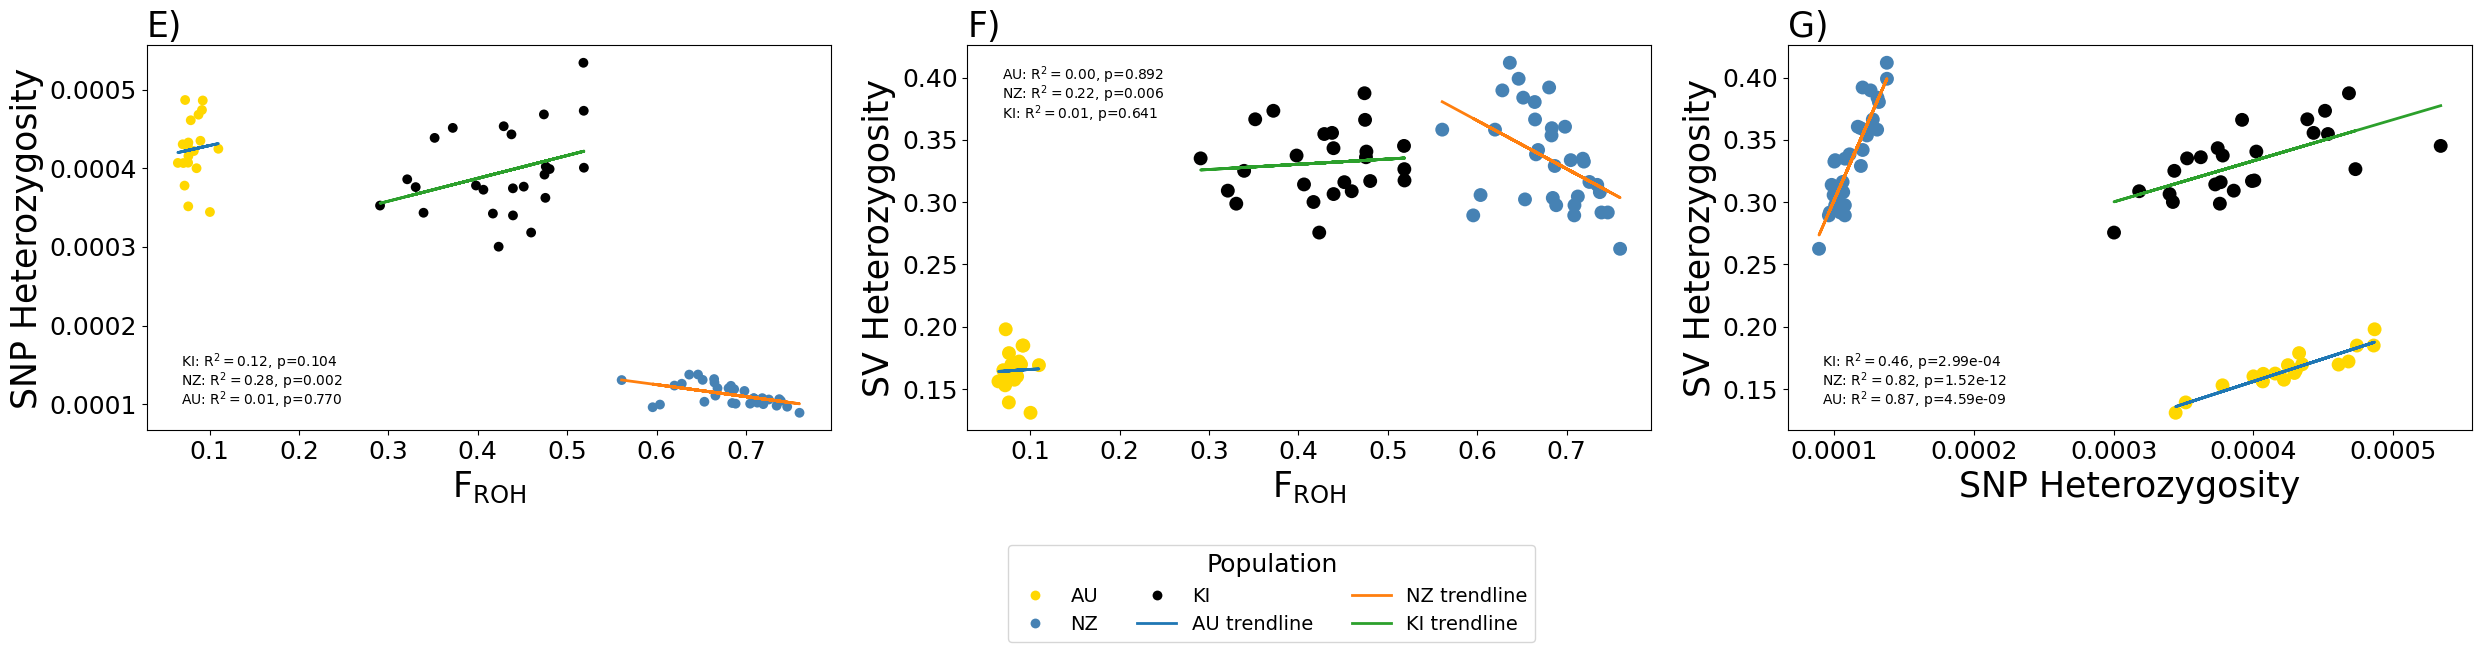

In [7]:
palette = ['gold', 'steelblue', 'black']

excluded_samples =['TI102', 'TI89', 'TI62', 'TI65', 'TI82', 'TI83', 'TI88', 'TI90', 'TI98', 'TI94', 'TI64', 'TI66', 'TI86', 'TI100', 'TI52', 'TI70', 'TI87']
low_depth_samps = ['SND04', 'SND11', 'SP02', 'TI21', 'TI36']

roh = pd.read_csv('rohan/ROHs.tsv', sep='\t')
roh = roh[~roh['Sample'].isin(excluded_samples)]
roh = roh[~roh['Sample'].isin(low_depth_samps)]

roh_len = roh.groupby(['Sample', 'Size Class', 'Population'])['ROH Length'].sum().reset_index(name='ROH Total')
roh_len['Froh'] = roh_len['ROH Total'] / 1088797119

het = pd.read_csv('angsd/individual_het.tsv', delimiter='\t')
het = het[~het['Sample'].isin(excluded_samples)]
het = het[~het['Sample'].isin(low_depth_samps)]
het['Heterozygosity'] = het['Heterozygous Sites'] / (het['Homozygous Ref Sites'] + het['Heterozygous Sites'] + het['Homozygous Alt Sites'])
het = het[het['Dataset'] == 'whole-genome']

sv_het = pd.read_csv('smoove/sv_het.tsv', delimiter='\t')
sv_het = sv_het[~sv_het['Sample'].isin(excluded_samples)]
sv_het = sv_het[~sv_het['Sample'].isin(low_depth_samps)]
sv_het['Heterozygosity'] = sv_het['Heterozygous'] / (sv_het['Homozygous Reference'] + sv_het['Heterozygous'] + sv_het['Homozygous Alternate'])
sv_het = sv_het[sv_het['Dataset']=='private']

# Merge data
diversity = pd.merge(het, roh_len, on=['Sample', 'Population'])
svdiversity = pd.merge(sv_het, roh_len, on=['Sample', 'Population'])
totalhet = pd.merge(het, sv_het, on=['Sample', 'Population'])

# Plot
order= ['AU', 'NZ', 'KI']

fig, ax = plt.subplots(1, 3, figsize=(30, 5), sharex=False, sharey=False)

sns.scatterplot(diversity.groupby(['Sample', 'Population', 'Heterozygosity'])['Froh'].sum().reset_index(), x="Froh", y="Heterozygosity", hue="Population", palette=palette, hue_order=order, s=50, edgecolor='none', ax=ax[0])
ax[0].legend(title='Population', loc='upper right')
ax[0].set_xlabel("$F_{ROH}$", fontsize=25)
ax[0].set_ylabel('SNP Heterozygosity', fontsize=25)
ax[0].set_title('E)', fontsize=25, loc='left')
add_trendline_and_r2_by_hue(ax[0], diversity.groupby(['Sample', 'Population', 'Heterozygosity'])['Froh'].sum().reset_index(), 'Froh', 'Heterozygosity', 'Population')

sns.scatterplot(svdiversity.groupby(['Sample', 'Population', 'Heterozygosity'])['Froh'].sum().reset_index(), x="Froh", y="Heterozygosity", hue="Population", palette=palette, hue_order=order, s=100, edgecolor='none', ax=ax[1])
ax[1].legend(title='Population', loc='upper right')
ax[1].set_xlabel("$F_{ROH}$", fontsize=25)
ax[1].set_ylabel('SV Heterozygosity', fontsize=25)
ax[1].set_title('F)', fontsize=25, loc='left')
add_trendline_and_r2_by_hue(ax[1], svdiversity.groupby(['Sample', 'Population', 'Heterozygosity'])['Froh'].sum().reset_index(), 'Froh', 'Heterozygosity', 'Population', position='top')

sns.scatterplot(data=totalhet, x='Heterozygosity_x', y='Heterozygosity_y', hue='Population', palette=palette, hue_order=order, s=100, edgecolor='none', ax=ax[2])
ax[2].legend(loc='upper right')
ax[2].set_xlabel('SNP Heterozygosity', fontsize=25)
ax[2].set_ylabel('SV Heterozygosity', fontsize=25)
ax[2].set_title('G)', fontsize=25, loc='left')
add_trendline_and_r2_by_hue(ax[2], totalhet.groupby(['Sample', 'Population', 'Heterozygosity_x'])['Heterozygosity_y'].sum().reset_index(), 'Heterozygosity_x', 'Heterozygosity_y', 'Population')

# Remove individual legends
for a in ax:
    a.legend_.remove()

# Add a single, shared legend
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles, labels, title='Population', title_fontsize=18,
    loc='upper center', bbox_to_anchor=(0.5, -0.1), 
    ncol=len(order), fontsize=14
)

for a in ax:
    a.tick_params(axis='both', which='major', labelsize=18)

# Save the plot
plt.savefig('Git_Repos/2026_S_nereis_Cons_Gen/Figures/Fig2_roh_het_relationship.png', dpi=600, bbox_inches='tight')

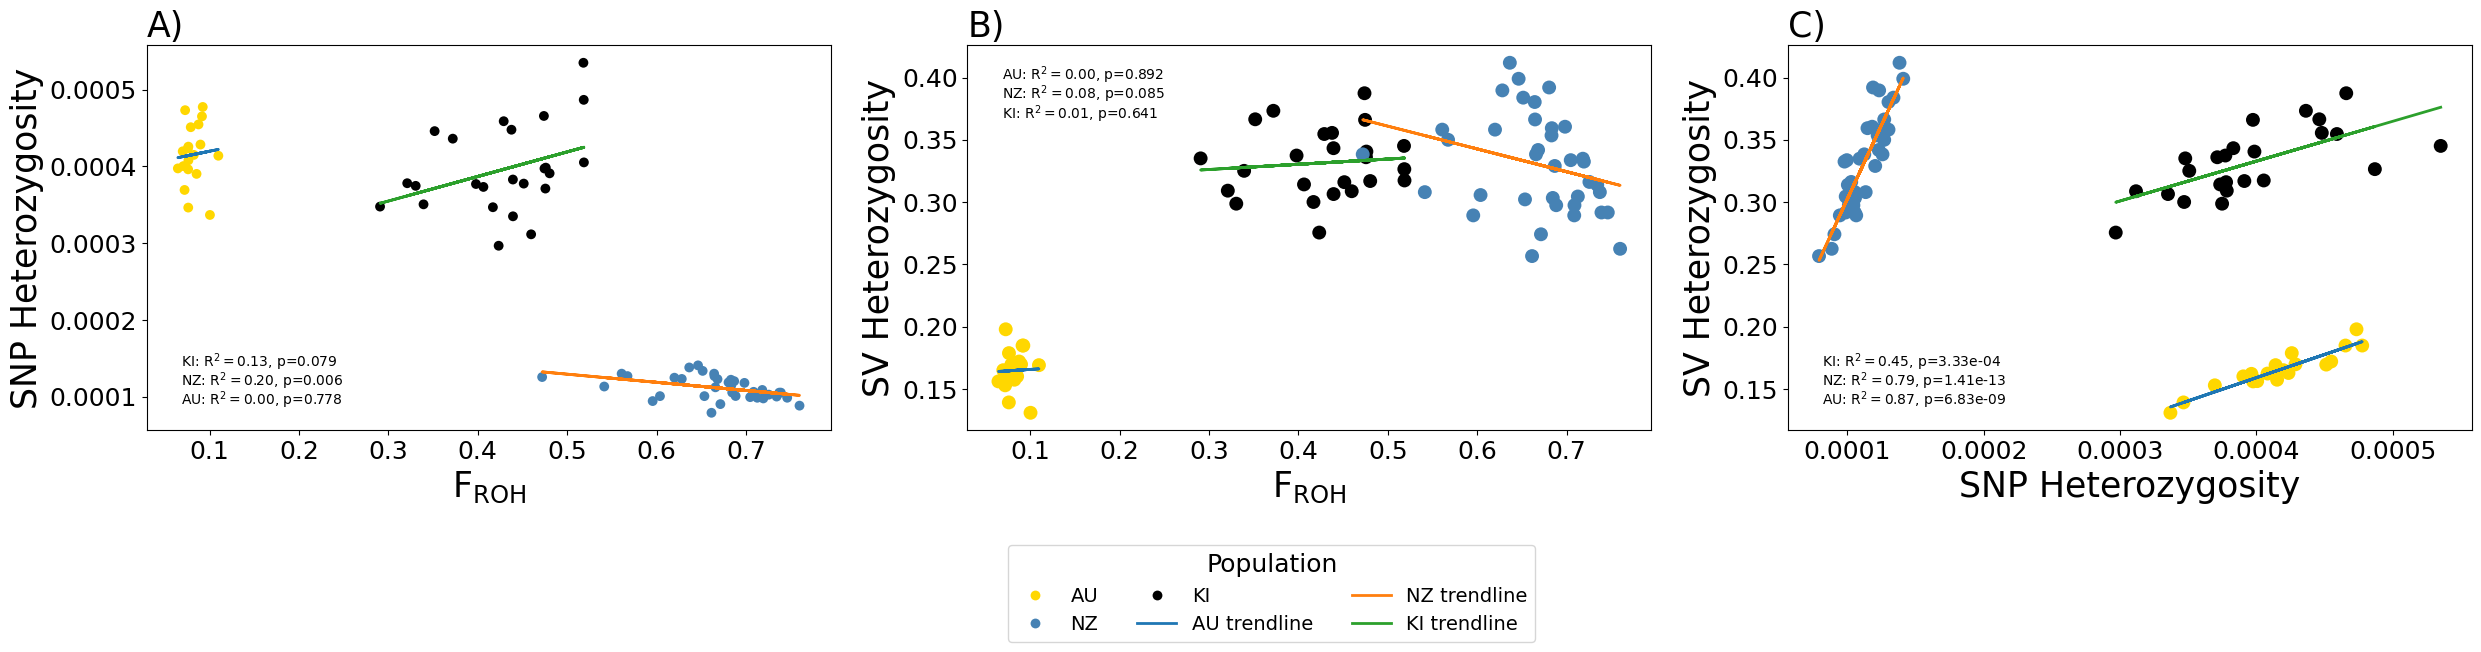

In [ ]:
palette = ['gold', 'steelblue', 'black']

excluded_samples =['TI102', 'TI89', 'TI62', 'TI65', 'TI82', 'TI83', 'TI88', 'TI90', 'TI98', 'TI94', 'TI64', 'TI66', 'TI86', 'TI100', 'TI52', 'TI70', 'TI87']

roh = pd.read_csv('rohan/ROHs.tsv', sep='\t')
roh = roh[~roh['Sample'].isin(excluded_samples)]

roh_len = roh.groupby(['Sample', 'Size Class', 'Population'])['ROH Length'].sum().reset_index(name='ROH Total')
roh_len['Froh'] = roh_len['ROH Total'] / 1088797119

het = pd.read_csv('angsd/individual_het.tsv', delimiter='\t')
het = het[~het['Sample'].isin(excluded_samples)]
het['Heterozygosity'] = het['Heterozygous Sites'] / (het['Homozygous Ref Sites'] + het['Heterozygous Sites'] + het['Homozygous Alt Sites'])
het = het[het['Dataset'] == 'neutral']

sv_het = pd.read_csv('smoove/sv_het.tsv', delimiter='\t')
sv_het = sv_het[~sv_het['Sample'].isin(excluded_samples)]
sv_het['Heterozygosity'] = sv_het['Heterozygous'] / (sv_het['Homozygous Reference'] + sv_het['Heterozygous'] + sv_het['Homozygous Alternate'])
sv_het = sv_het[sv_het['Dataset']=='private']

# Merge data
diversity = pd.merge(het, roh_len, on=['Sample', 'Population'])
svdiversity = pd.merge(sv_het, roh_len, on=['Sample', 'Population'])
totalhet = pd.merge(het, sv_het, on=['Sample', 'Population'])

# Plot
order= ['AU', 'NZ', 'KI']

fig, ax = plt.subplots(1, 3, figsize=(30, 5), sharex=False, sharey=False)

sns.scatterplot(diversity.groupby(['Sample', 'Population', 'Heterozygosity'])['Froh'].sum().reset_index(), x="Froh", y="Heterozygosity", hue="Population", palette=palette, hue_order=order, s=50, edgecolor='none', ax=ax[0])
ax[0].legend(title='Population', loc='upper right')
ax[0].set_xlabel("$F_{ROH}$", fontsize=25)
ax[0].set_ylabel('SNP Heterozygosity', fontsize=25)
ax[0].set_title('A)', fontsize=25, loc='left')
add_trendline_and_r2_by_hue(ax[0], diversity.groupby(['Sample', 'Population', 'Heterozygosity'])['Froh'].sum().reset_index(), 'Froh', 'Heterozygosity', 'Population')

sns.scatterplot(svdiversity.groupby(['Sample', 'Population', 'Heterozygosity'])['Froh'].sum().reset_index(), x="Froh", y="Heterozygosity", hue="Population", palette=palette, hue_order=order, s=100, edgecolor='none', ax=ax[1])
ax[1].legend(title='Population', loc='upper right')
ax[1].set_xlabel("$F_{ROH}$", fontsize=25)
ax[1].set_ylabel('SV Heterozygosity', fontsize=25)
ax[1].set_title('B)', fontsize=25, loc='left')
add_trendline_and_r2_by_hue(ax[1], svdiversity.groupby(['Sample', 'Population', 'Heterozygosity'])['Froh'].sum().reset_index(), 'Froh', 'Heterozygosity', 'Population', position='top')

sns.scatterplot(data=totalhet, x='Heterozygosity_x', y='Heterozygosity_y', hue='Population', palette=palette, hue_order=order, s=100, edgecolor='none', ax=ax[2])
ax[2].legend(loc='upper right')
ax[2].set_xlabel('SNP Heterozygosity', fontsize=25)
ax[2].set_ylabel('SV Heterozygosity', fontsize=25)
ax[2].set_title('C)', fontsize=25, loc='left')
add_trendline_and_r2_by_hue(ax[2], totalhet.groupby(['Sample', 'Population', 'Heterozygosity_x'])['Heterozygosity_y'].sum().reset_index(), 'Heterozygosity_x', 'Heterozygosity_y', 'Population')

# Remove individual legends
for a in ax:
    a.legend_.remove()

# Add a single, shared legend
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(
    handles, labels, title='Population', title_fontsize=18,
    loc='upper center', bbox_to_anchor=(0.5, -0.1), 
    ncol=len(order), fontsize=14
)

for a in ax:
    a.tick_params(axis='both', which='major', labelsize=18)

# Save the plot
plt.savefig('Git_Repos/2026_S_nereis_Cons_Gen/Figures/Supp_Fig_roh_het_relationship.png', dpi=600, bbox_inches='tight')

In [45]:
roh = pd.read_csv('rohan/ROHs.tsv', sep='\t')
roh = roh[~roh['Sample'].isin(excluded_samples)]
roh = roh[~roh['Sample'].isin(low_depth_samps)]

roh_len = roh.groupby(['Sample', 'Size Class', 'Population'])['ROH Length'].sum().reset_index(name='ROH Total')
roh_len['Froh'] = roh_len['ROH Total'] / 1088797119

roh_len.head()

,Sample,Size Class,Population,ROH Total,Froh
0,AU01,Long ROH,AU,17200000,0.015797
1,AU01,Medium ROH,AU,36700000,0.033707
2,AU01,Short ROH,AU,45800000,0.042065
3,AU03,Long ROH,AU,34900000,0.032054
4,AU03,Medium ROH,AU,40400000,0.037105


In [46]:
diversity = pd.merge(het, roh_len, on=['Sample', 'Population'])
svdiversity = pd.merge(sv_het, roh_len, on=['Sample', 'Population'])

diversity.head()

,Sample,Homozygous Ref Sites,Heterozygous Sites,Homozygous Alt Sites,Population,Dataset,Heterozygosity,Size Class,ROH Total,Froh
0,AU01,1.065313e+09,515986.810318,2.251555e+07,AU,whole-genome,0.000474,Long ROH,17200000,0.015797
1,AU01,1.065313e+09,515986.810318,2.251555e+07,AU,whole-genome,0.000474,Medium ROH,36700000,0.033707
2,AU01,1.065313e+09,515986.810318,2.251555e+07,AU,whole-genome,0.000474,Short ROH,45800000,0.042065
3,AU03,1.063127e+09,461294.455040,2.242107e+07,AU,whole-genome,0.000425,Long ROH,34900000,0.032054
4,AU03,1.063127e+09,461294.455040,2.242107e+07,AU,whole-genome,0.000425,Medium ROH,40400000,0.037105


/tmp/ipykernel_10113/2866785969.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


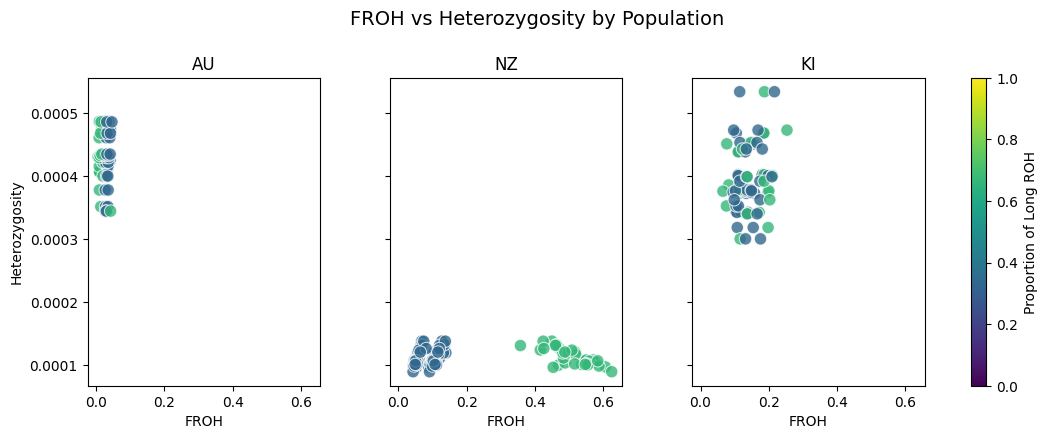

In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

# Pivot to wide format, keeping Population
df_wide = diversity.pivot_table(
    index=["Sample","Population","Froh","Heterozygosity"],
    columns="Size Class",
    values="ROH Total",
    fill_value=0
).reset_index()

# Compute proportion of long ROH
df_wide['Prop_Long_ROH'] = df_wide['Long ROH'] / df_wide[['Short ROH','Medium ROH','Long ROH']].sum(axis=1)

# --- Create figure with space for colorbar ---
# --- Create figure with 3 subplots, shared axes ---
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True, gridspec_kw={'wspace':0.3})

# Explicitly plot each population with Seaborn
sns.scatterplot(data=df_wide[df_wide['Population']=='AU'], x='Froh', y='Heterozygosity', hue='Prop_Long_ROH', palette='viridis',
    s=80, alpha=0.8, ax=axes[0], legend=False)
axes[0].set_title('AU')
axes[0].set_xlabel('FROH')
axes[0].set_ylabel('Heterozygosity')

sns.scatterplot(data=df_wide[df_wide['Population']=='NZ'], x='Froh', y='Heterozygosity', hue='Prop_Long_ROH', palette='viridis',
    s=80, alpha=0.8, ax=axes[1], legend=False)
axes[1].set_title('NZ')
axes[1].set_xlabel('FROH')
axes[1].set_ylabel('Heterozygosity')

sns.scatterplot(data=df_wide[df_wide['Population']=='KI'], x='Froh', y='Heterozygosity', hue='Prop_Long_ROH', palette='viridis',
    s=80, alpha=0.8, ax=axes[2], legend=False)
axes[2].set_title('KI')
axes[2].set_xlabel('FROH')
axes[2].set_ylabel('Heterozygosity')

# --- Add a single colorbar for all three axes ---
norm = mpl.colors.Normalize(vmin=df_wide['Prop_Long_ROH'].min(), vmax=df_wide['Prop_Long_ROH'].max())
sm = mpl.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), orientation='vertical', fraction=0.05, pad=0.05)
cbar.set_label('Proportion of Long ROH')

fig.suptitle("FROH vs Heterozygosity by Population", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()